In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from matplotlib.lines import Line2D
from matplotlib.legend_handler import HandlerTuple
import matplotlib

from brokenaxes import brokenaxes

In [ ]:
##  PLOS

plt.rcParams.update({
    # Fonts - Times, 8-12 pt
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "font.size": 12,                  # Base size 8-12 pt

    # Axes
    "axes.titlesize": 12,             # Axis title size
    "axes.labelsize": 12,             # Axis label size
    "axes.labelweight": "normal",     # Normal weight
    "axes.titleweight": "normal",     # Normal weight for titles

    # Ticks
    "xtick.labelsize": 9,             # X tick label size (8-12)
    "ytick.labelsize": 9,             # Y tick label size (8-12)
    "xtick.direction": "in",          # Tick direction
    "ytick.direction": "in",          # Tick direction

    # Legends
    "legend.fontsize": 12,            # Legend text size (8-12)
    "legend.title_fontsize": 12,      # Legend title size (8-12)
    "legend.loc": 'best',             # Automatic location

    # Resolution
    "figure.dpi": 500,                # Display DPI
    "savefig.dpi": 500,               # Save DPI (300-600)
    "savefig.bbox": "tight",          # Crop whitespace

    # Without LaTeX
    "text.usetex": False,             # PLOS does not accept LaTeX EPS
    "mathtext.fontset": "dejavuserif",# Match math fonts to serif

    # Figsize ?
    # "figure.figsize": (16, 6),       # Figsize
    # "figure.figsize": (8, 6),       # Figsize
    # Make text editable in Inkscape
    "svg.fonttype": 'none',
})

In [3]:
## Reusable color utility
# I use this one
import numpy as np
import matplotlib.pyplot as plt

def make_color_map(values, cmap, vmin=0.25, vmax=1.0):
    '''
    Function that takes array of values and make a colormap for them
    '''
    values_sorted = sorted(values)
    colors = cmap(np.linspace(vmin, vmax, len(values)))
    return dict(zip(values_sorted, colors))

# To be given value
v_rest = [-22, -17, -12.3, -8.5]
pqif_vector = [0, 0.25, 0.5, 0.75, 1]

# Make colors once
color_map_vrest = make_color_map(v_rest, plt.cm.Reds)  # Reds for vrest
color_map_pqif = make_color_map(pqif_vector[1:-1], plt.cm.Greens)  # Greens for pqif

# Explicit endpoints for pqif
color_map_pqif[pqif_vector[0]] = 'black'
color_map_pqif[pqif_vector[-1]] = 'steelblue'


In [5]:
print("-" * 30)

------------------------------


In [4]:
import pandas as pd
from pathlib import Path

# -----------------------------
# 1. Create a simple DataFrame
# -----------------------------
data = {
    "name": ["Alice", "Bob", "Charlie"],
    "age": [25, 30, 35],
    "score": [88.5, 92.0, 79.5],
}

df = pd.DataFrame(data)

# -----------------------------
# 2. Define OneDrive path
# -----------------------------
# Example (Windows):
# Path(r"C:\Users\YourUsername\OneDrive\test_folder")
#
# Example (Mac):
# Path("/Users/YourUsername/OneDrive/test_folder")

# Onedrive base where evertything will be saved
ONEDRIVE_BASE = Path(r"C:\Users\Silje\OneDrive\Dokumenter\mscneuroscience20242026\nevr3901\simulations_folder")

# Optional: ensure the folder exists
ONEDRIVE_BASE.mkdir(parents=True, exist_ok=True)

# -----------------------------
# 3. Save DataFrame to CSV
# -----------------------------
# csv_path = ONEDRIVE_BASE / "new_test_dataframe.csv"
# df.to_csv(csv_path, index=False)

# print(f"CSV file successfully saved to:\n{csv_path}")




In [18]:
# figure_folder = 'figures_omitzero'

figure_folder = 'C:/Users/Silje/OneDrive/Dokumenter/mscneuroscience20242026/nevr3901/simulations_folder/figures_omitzero/changes'

In [6]:
import pandas as pd
import numpy as np
import matplotlib
import sys


########## Loop variables ##########

vrest = [-8.5, -12.3, -17, -22]
slope = [14.44, 10.68, 8.65, 7.18]
slope_qif = 10.74
all_slopes = [14.44, 10.68, 10.74, 8.65, 7.18]
pqif_number = [0, 0.25, 0.5, 0.75, 1]
pqif_homogenous = [0, 1]
dynamics = ['oscillations', 'sequences']
# dynamics = ['oscillations']
seed_number = [i for i in range(0, 50)] 


########## Dataframe and dictionary ##########

rows = []  # Container for rows of dataframe
weights_unfiltered_dict = {}  # Dictionary for weight arrays
weights_filtered_dict = {}

for dyn in dynamics:

    simulation_number = [i for i in range(1,5)] if dyn == 'oscillations' else [i for i in range(9,13)]

    for sim, vr, f in zip(simulation_number, vrest, slope):
        for pqif in pqif_number:
            for seed in seed_number:

                simulation_id = f'{dyn}_{sim}_{pqif}_{seed}'  # Shared across dataframe and dictionary

                # ------------------------------ Initial matrix (with zero weights) ------------------------------
                file_path_iloop_0 = ONEDRIVE_BASE / f"simulation_{sim}_connectivity_matrix\simulation_{sim}_connectivity_pqif_{pqif}_iloop_0_seed_{seed}"
                # file_path_iloop_0 = f"{dyn}\simulation_{sim}\simulation_{sim}_connectivity_matrix\simulation_{sim}_connectivity_pqif_{pqif}_iloop_0_seed_{seed}"

                M = np.loadtxt(file_path_iloop_0, delimiter=',')

                # ------------------------------ print some info about it ------------------------------

                zeros = M == 0  # matrix indicating which weights were initialized to zero
                num_zero_weights = np.sum(zeros)
                num_non_zero_weights = np.sum(~zeros)
                frac_zero_weights = f"{np.sum(zeros) / M.size:.2f}" # should be around 0.7

                # ------------------------------ Matrix after training ------------------------------

                # Load matrix
                file_path_iloop_11 = ONEDRIVE_BASE / f'simulation_{sim}_connectivity_matrix\simulation_{sim}_connectivity_pqif_{pqif}_iloop_11_seed_{seed}'
                # file_path_iloop_11 = f'{dyn}\simulation_{sim}\simulation_{sim}_connectivity_matrix\simulation_{sim}_connectivity_pqif_{pqif}_iloop_11_seed_{seed}'
                W_unfiltered = np.loadtxt(file_path_iloop_11, delimiter=',')

                # ------------------------------ Filtered data: Exclude weights initialized to zero ------------------------------
                W_filtered = W_unfiltered[~zeros]  # Omit zeros, and flatten to 1D

                # weights_filtered = M_final_filt.flatten()  # with filtering
                weights_filtered_dict[simulation_id] = W_filtered

                mean_filtered = W_filtered.mean()
                std_filtered = W_filtered.std()




                # ------------------------------ Unfiltered data ------------------------------

                # weights_df = pd.DataFrame(M_final)  # if needed?
                weights = W_unfiltered.flatten()  # flatten weights without filtering
                std = np.std(weights)
                mean = np.mean(weights)
                weights_unfiltered_dict[simulation_id] = weights  # Dictionary mapping simulationID to weight array FLATTENED VERSION
                # weights_dict[simulation_id] = weights_df  # Dictionary mapping simulationID to weight array





                # ------------------------------ Final stats ------------------------------


                if pqif == 1:
                    vr = None
                    f = slope_qif


                row = [simulation_id, dyn, sim, vr, f, pqif, seed, std, mean, mean_filtered, std_filtered, num_zero_weights, num_non_zero_weights, frac_zero_weights]  # Store all data associated with the connectivity matrix + a simulationID to the weights in dictionary
                rows.append(row)  # Append row to what becomes the dataframe later

########## Make dataframe ##########

columns = ['simulationID', 'dynamic', 'simulation', 'vrest', 'slope', 'pqif', 'seed', 'std', 'mean', 'mean_filtered', 'std_filtered', 'num_zero_weights', 'num_non_zero_weights', 'frac_zero_weights']
df = pd.DataFrame(rows, columns=columns)


########## Make a copy of dataframe for further use ##########

wDF = df.copy()

########## Print statements to control ##########
print(wDF.head())
print(wDF.tail())
# print(weights_dict)
# for i in weights_dict.items():
#     print(i)

wDF.to_csv("stats_connectivitymatrix_with_filters2.csv", index=False)

         simulationID       dynamic  simulation  vrest  slope  pqif  seed  \
0  oscillations_1_0_0  oscillations           1   -8.5  14.44   0.0     0   
1  oscillations_1_0_1  oscillations           1   -8.5  14.44   0.0     1   
2  oscillations_1_0_2  oscillations           1   -8.5  14.44   0.0     2   
3  oscillations_1_0_3  oscillations           1   -8.5  14.44   0.0     3   
4  oscillations_1_0_4  oscillations           1   -8.5  14.44   0.0     4   

        std      mean  mean_filtered  std_filtered  num_zero_weights  \
0  0.255446 -0.000068      -0.000227      0.467568             28061   
1  0.233008  0.000042       0.000142      0.426534             28063   
2  0.233865 -0.000029      -0.000096      0.428067             28061   
3  0.239014 -0.000076      -0.000255      0.437272             28049   
4  0.234006 -0.000066      -0.000220      0.428056             28046   

   num_non_zero_weights frac_zero_weights  
0                 11939              0.70  
1               

In [7]:
wDF

,simulationID,dynamic,simulation,vrest,slope,pqif,seed,std,mean,mean_filtered,std_filtered,num_zero_weights,num_non_zero_weights,frac_zero_weights
0,oscillations_1_0_0,oscillations,1,-8.5,14.44,0.0,0,0.255446,-0.000068,-0.000227,0.467568,28061,11939,0.70
1,oscillations_1_0_1,oscillations,1,-8.5,14.44,0.0,1,0.233008,0.000042,0.000142,0.426534,28063,11937,0.70
2,oscillations_1_0_2,oscillations,1,-8.5,14.44,0.0,2,0.233865,-0.000029,-0.000096,0.428067,28061,11939,0.70
3,oscillations_1_0_3,oscillations,1,-8.5,14.44,0.0,3,0.239014,-0.000076,-0.000255,0.437272,28049,11951,0.70
4,oscillations_1_0_4,oscillations,1,-8.5,14.44,0.0,4,0.234006,-0.000066,-0.000220,0.428056,28046,11954,0.70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,sequences_12_1_45,sequences,12,NaN,10.74,1.0,45,0.213726,0.021462,0.071947,0.386649,28068,11932,0.70
1996,sequences_12_1_46,sequences,12,NaN,10.74,1.0,46,0.211047,0.021321,0.071408,0.381578,28057,11943,0.70
1997,sequences_12_1_47,sequences,12,NaN,10.74,1.0,47,0.218655,0.021589,0.072336,0.395630,28062,11938,0.70
1998,sequences_12_1_48,sequences,12,NaN,10.74,1.0,48,0.197260,0.021970,0.073626,0.355804,28064,11936,0.70


In [3]:
wDF

,simulationID,dynamic,simulation,vrest,slope,pqif,seed,std,mean,mean_filtered,std_filtered,num_zero_weights,num_non_zero_weights,frac_zero_weights
0,oscillations_1_0_0,oscillations,1,-8.5,14.44,0.0,0,0.255446,-0.000068,-0.000227,0.467568,28061,11939,0.70
1,oscillations_1_0_1,oscillations,1,-8.5,14.44,0.0,1,0.233008,0.000042,0.000142,0.426534,28063,11937,0.70
2,oscillations_1_0_2,oscillations,1,-8.5,14.44,0.0,2,0.233865,-0.000029,-0.000096,0.428067,28061,11939,0.70
3,oscillations_1_0_3,oscillations,1,-8.5,14.44,0.0,3,0.239014,-0.000076,-0.000255,0.437272,28049,11951,0.70
4,oscillations_1_0_4,oscillations,1,-8.5,14.44,0.0,4,0.234006,-0.000066,-0.000220,0.428056,28046,11954,0.70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,sequences_12_1_45,sequences,12,NaN,10.74,1.0,45,0.213726,0.021462,0.071947,0.386649,28068,11932,0.70
1996,sequences_12_1_46,sequences,12,NaN,10.74,1.0,46,0.211047,0.021321,0.071408,0.381578,28057,11943,0.70
1997,sequences_12_1_47,sequences,12,NaN,10.74,1.0,47,0.218655,0.021589,0.072336,0.395630,28062,11938,0.70
1998,sequences_12_1_48,sequences,12,NaN,10.74,1.0,48,0.197260,0.021970,0.073626,0.355804,28064,11936,0.70


In [9]:
print(weights_filtered_dict)

{'oscillations_1_0_0': array([-6.18515236e-03, -2.22347267e-05, -6.28486984e-02, ...,
        1.46595407e+00,  8.58115234e-01,  1.13027522e+00], shape=(11939,)), 'oscillations_1_0_1': array([ 0.2669151 ,  0.21379404, -0.21934544, ..., -1.93163586,
        1.47471672, -0.09515838], shape=(11937,)), 'oscillations_1_0_2': array([ 0.06206474,  0.10322354,  0.03294752, ..., -1.05216726,
       -0.10774147, -1.41629501], shape=(11939,)), 'oscillations_1_0_3': array([-0.09473385, -0.04589277, -0.10242182, ...,  0.14759109,
       -0.44871914,  0.94576708], shape=(11951,)), 'oscillations_1_0_4': array([ 0.16883238,  0.03162842,  0.01198753, ..., -0.13655441,
        1.59198563, -0.11910531], shape=(11954,)), 'oscillations_1_0_5': array([ 0.08505303, -0.12563913, -0.10348269, ..., -0.07337157,
       -1.4176399 , -0.72634049], shape=(11944,)), 'oscillations_1_0_6': array([ 4.53000778e-02,  3.71579274e-01,  1.59804268e-01, ...,
       -1.73766058e-01, -6.94681608e-01,  6.79043190e-04], shape=(11

Used seed [2]


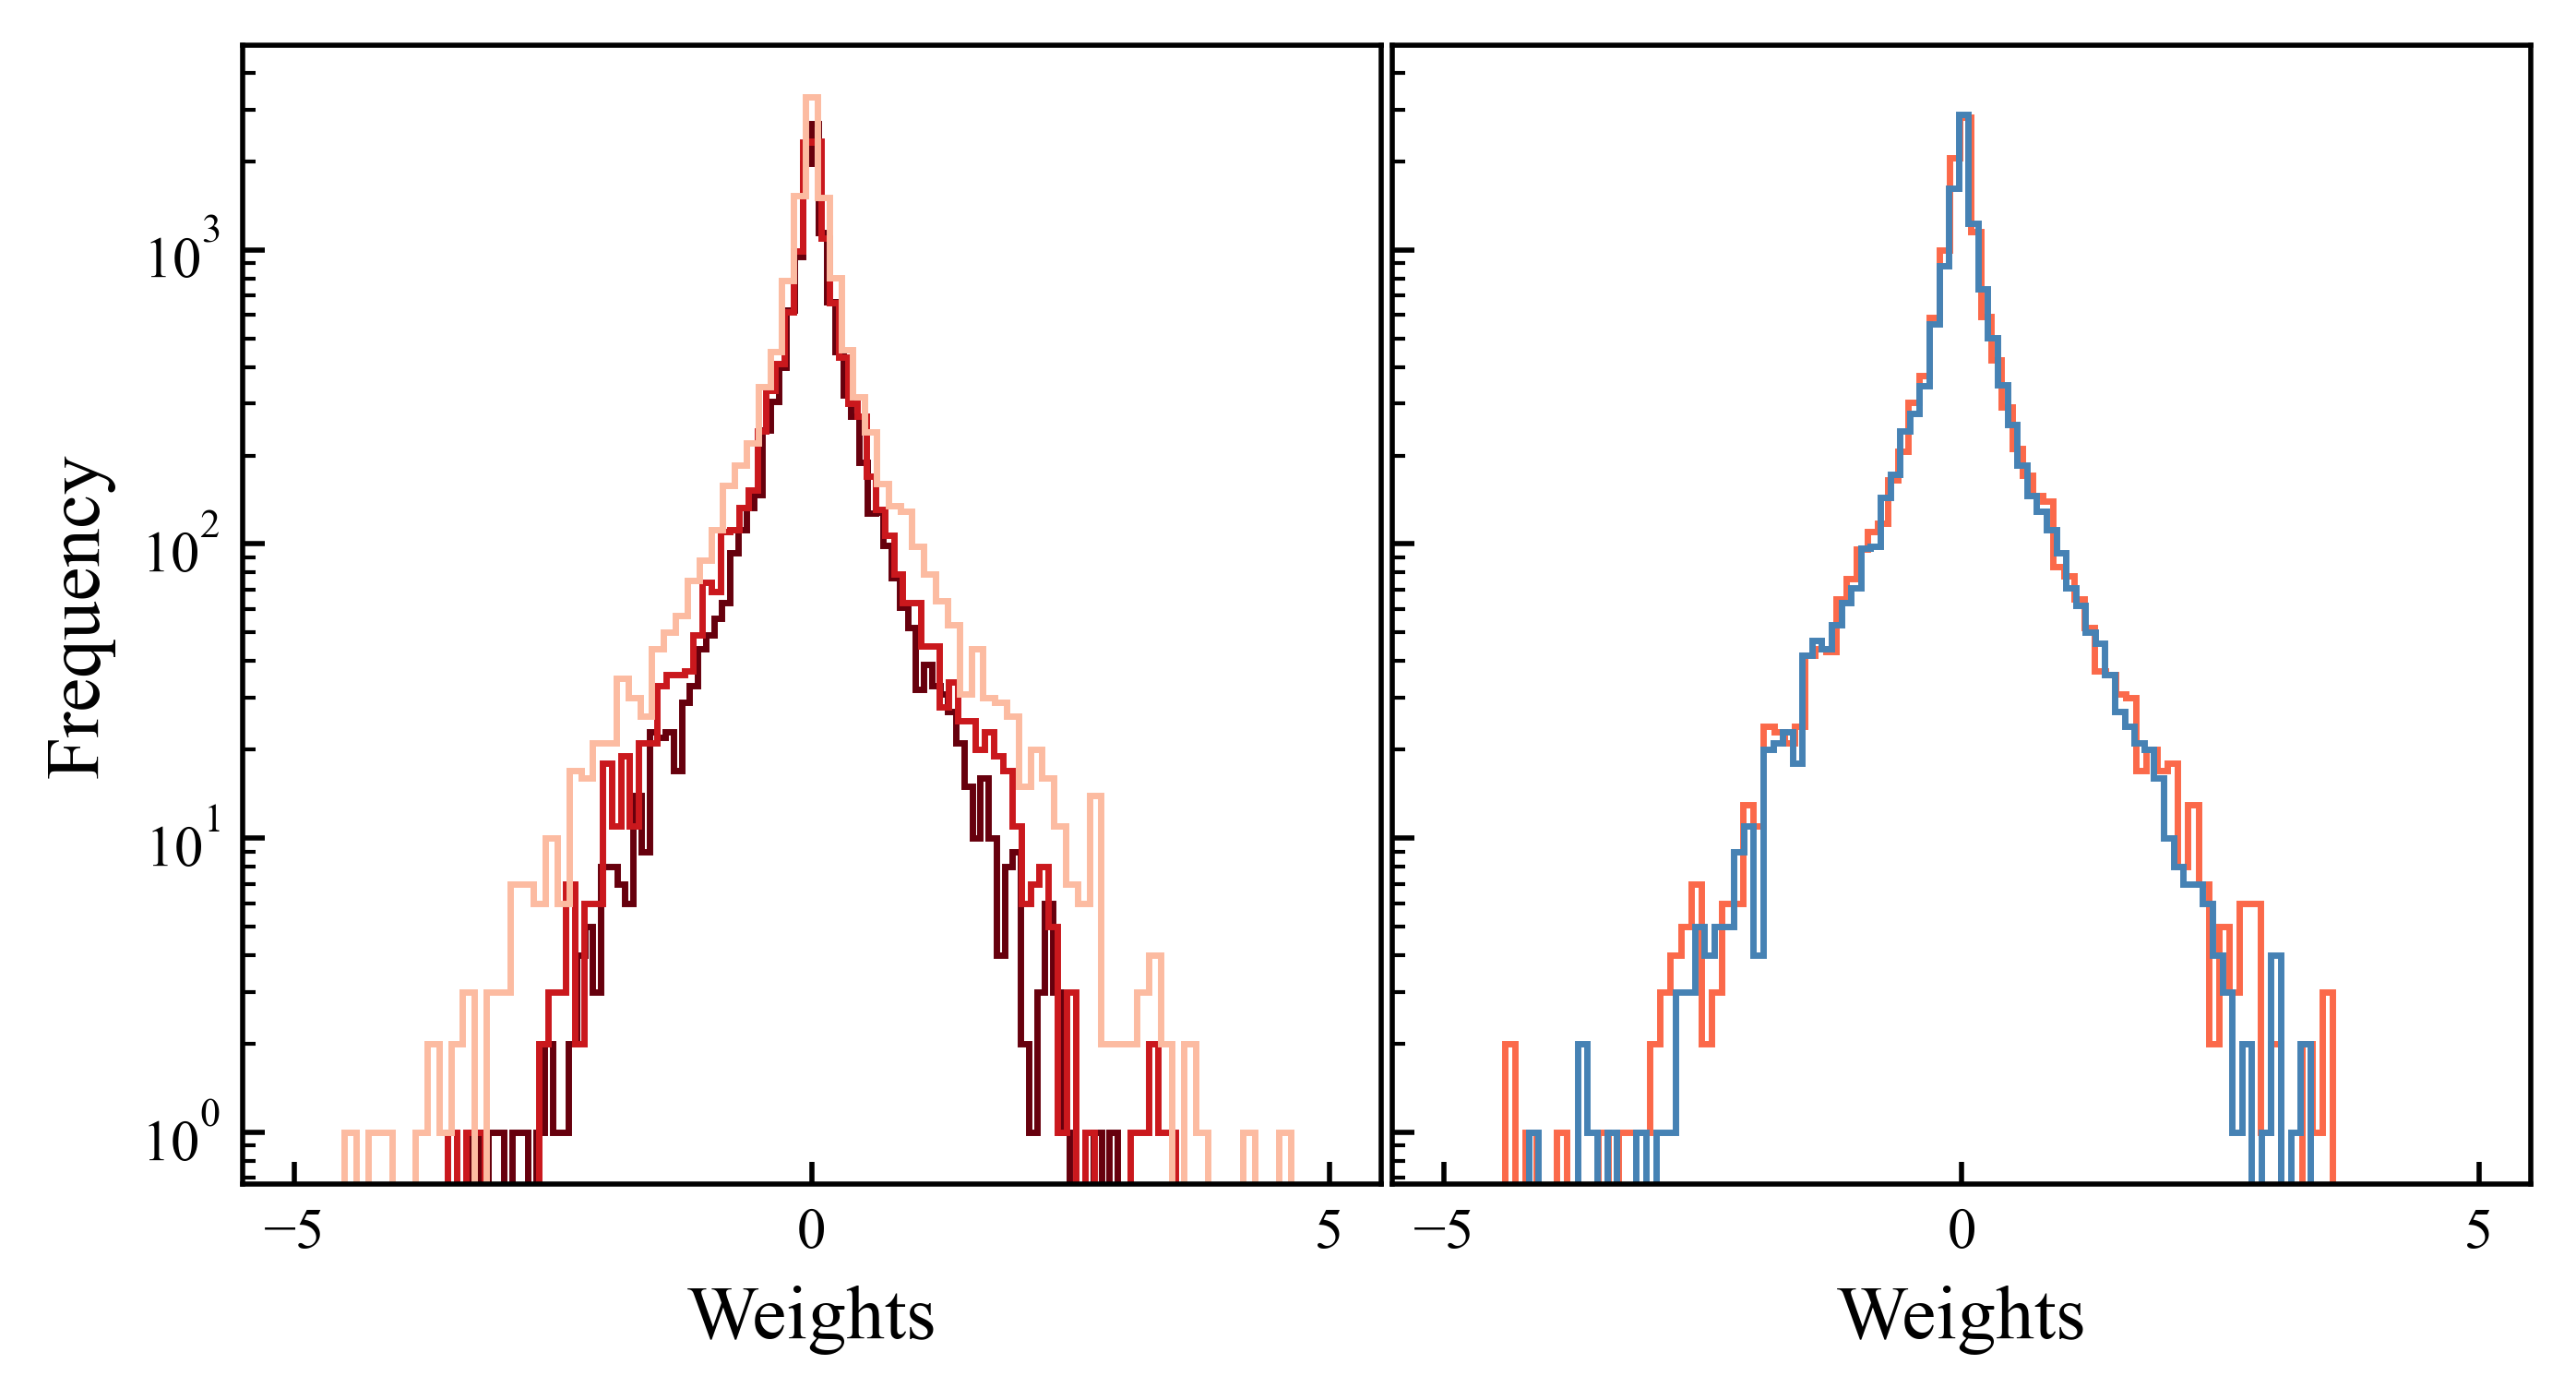

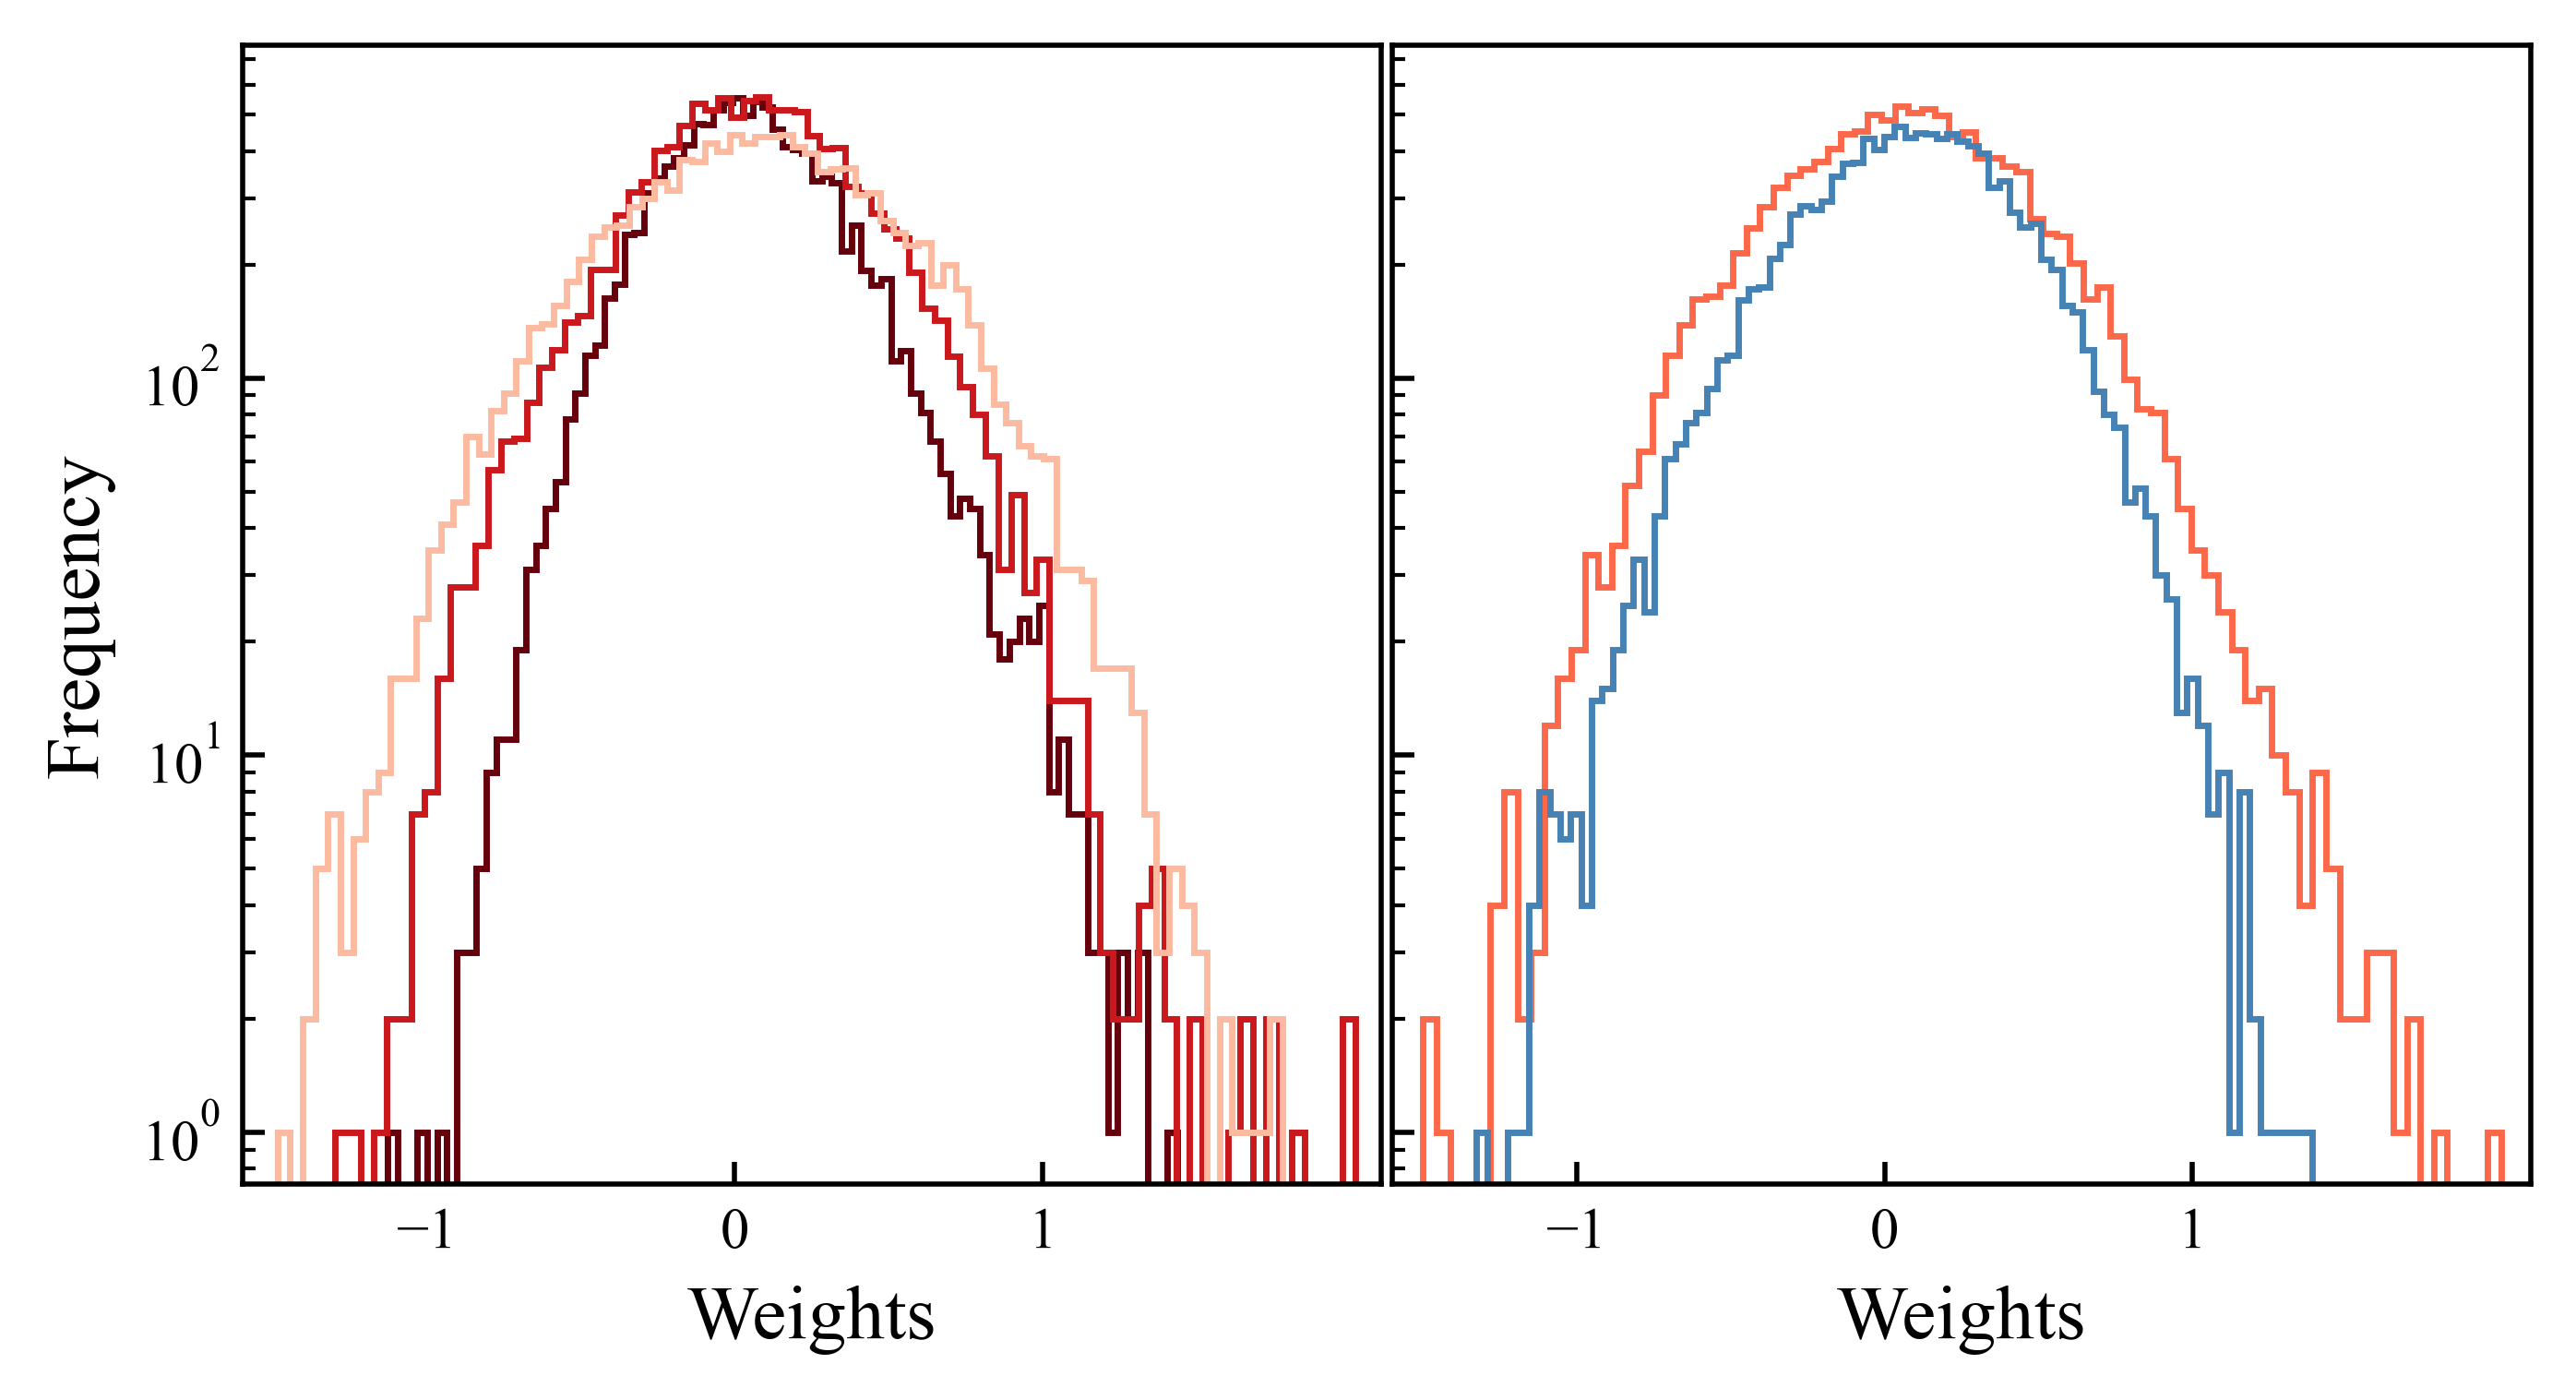

In [15]:
# ========== Histogram of weight distribution for homogenous networks ==========

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import sys
import os
import random
from matplotlib.patches import Patch


########## Loop variables ##########
vrest = [-8.5, -12.3, -17, -22]
slope = [14.44, 10.68, 8.65, 7.18]
slope_qif = [10.74]
all_slopes = [14.44, 10.68, 10.74, 8.65, 7.18]
pqif_number = [0, 0.25, 0.5, 0.75, 1]
pqif_homogenous = [0, 1]

dynamics = ['oscillations', 'sequences']
# dynamics = ['oscillations']

# seed_number = [i for i in range(0, 1)] # Only use one seed for this
seed_number = [random.randint(1, 49)]
seed_number = [2] 
print(f"Used seed {seed_number}")

rows = []

########## Figure loop ##########
for dyn in dynamics:

    simulation_number = [i for i in range(1,5)] if dyn == 'oscillations' else [i for i in range(9,13)]

    figname = f"{dyn}_homogenous_histo_weights_filtered.svg"

    #### Create figure and axes

    fig, (ax1, ax2) = plt.subplots(
        nrows=1, ncols=2,
        # figsize=(10,4),  # TODO review
        sharey=True
    )

    fig.subplots_adjust(
    wspace=0.01
)


    #### Figure control flow

    for sim, vr, f in zip(simulation_number, vrest, slope):
        for pqif in pqif_homogenous:
            for seed in seed_number:

                #### Take out values to plot

                df_filtered = wDF[(wDF['dynamic'] == dyn) & (wDF['simulation'] == sim) & (wDF['pqif'] == pqif) & (wDF['seed'] == seed)]  # Current row of dataframe with metadata

                ID = df_filtered['simulationID'].item()  # Simulation ID

                # current_weights_noflatten = weights_dict[ID].to_numpy()  # Weight array not flattened
                # current_weights = current_weights_noflatten.flatten()

                current_weights = weights_filtered_dict[ID]

                std = current_weights.std()
                mn = current_weights.mean()

                #### Color control flow
                if pqif == 1:
                    colors = 'steelblue'
                else:
                    colors = color_map_vrest[vr]

                if pqif == 0 and f in [14.44, 10.68, 7.18]:  # Left
                # if pqif == 0 and f in slope:  # Left
                # if pqif == 0 and f in [14.44]:  # Left

                    if sim == simulation_number[0]:  # LIF header in legend
                        label = f"LIF\n$F'$={f}"
                    else:
                        label = f"$F'$={f}"

                    ax1.hist(current_weights, bins=80, log=True, color=colors, alpha=1, linewidth=1, histtype='step', label=label)

                    
                elif f == 8.65:  # Right
                # elif pqif == 1 and sim == simulation_number[2]:
                # if sim == simulation_number[2]:
                    if pqif == 0:
                        label = f"LIF\n$F'$={f}"
                    else:
                        label = 'QIF'

                    ax2.hist(current_weights, bins=80, log=True, color=colors, alpha=1, linewidth=1, histtype='step', label=label)


                else:  # Ignore others
                    continue


    #### Shared formatting

    if dyn == 'oscillations':
        tick_positions = [-5, 0, 5]
        xlim = (-5.5, 5.5)
    elif dyn == 'sequences':
        tick_positions = [-1, 0, 1]
        xlim = (-1.6, 2.1)

    for ax in (ax1, ax2):
        ax.set_xlabel("Weights")
        ax.set_xticks(tick_positions)
        ax.set_xlim(xlim)
        ax.set_box_aspect(1)
    ax1.set_ylabel("Frequency")


    
    #### Save
    full_path = os.path.join(figure_folder, figname)
    plt.savefig(full_path, format="svg")

    # plt.tight_layout()
    plt.show()



# 2

Used seed [2]


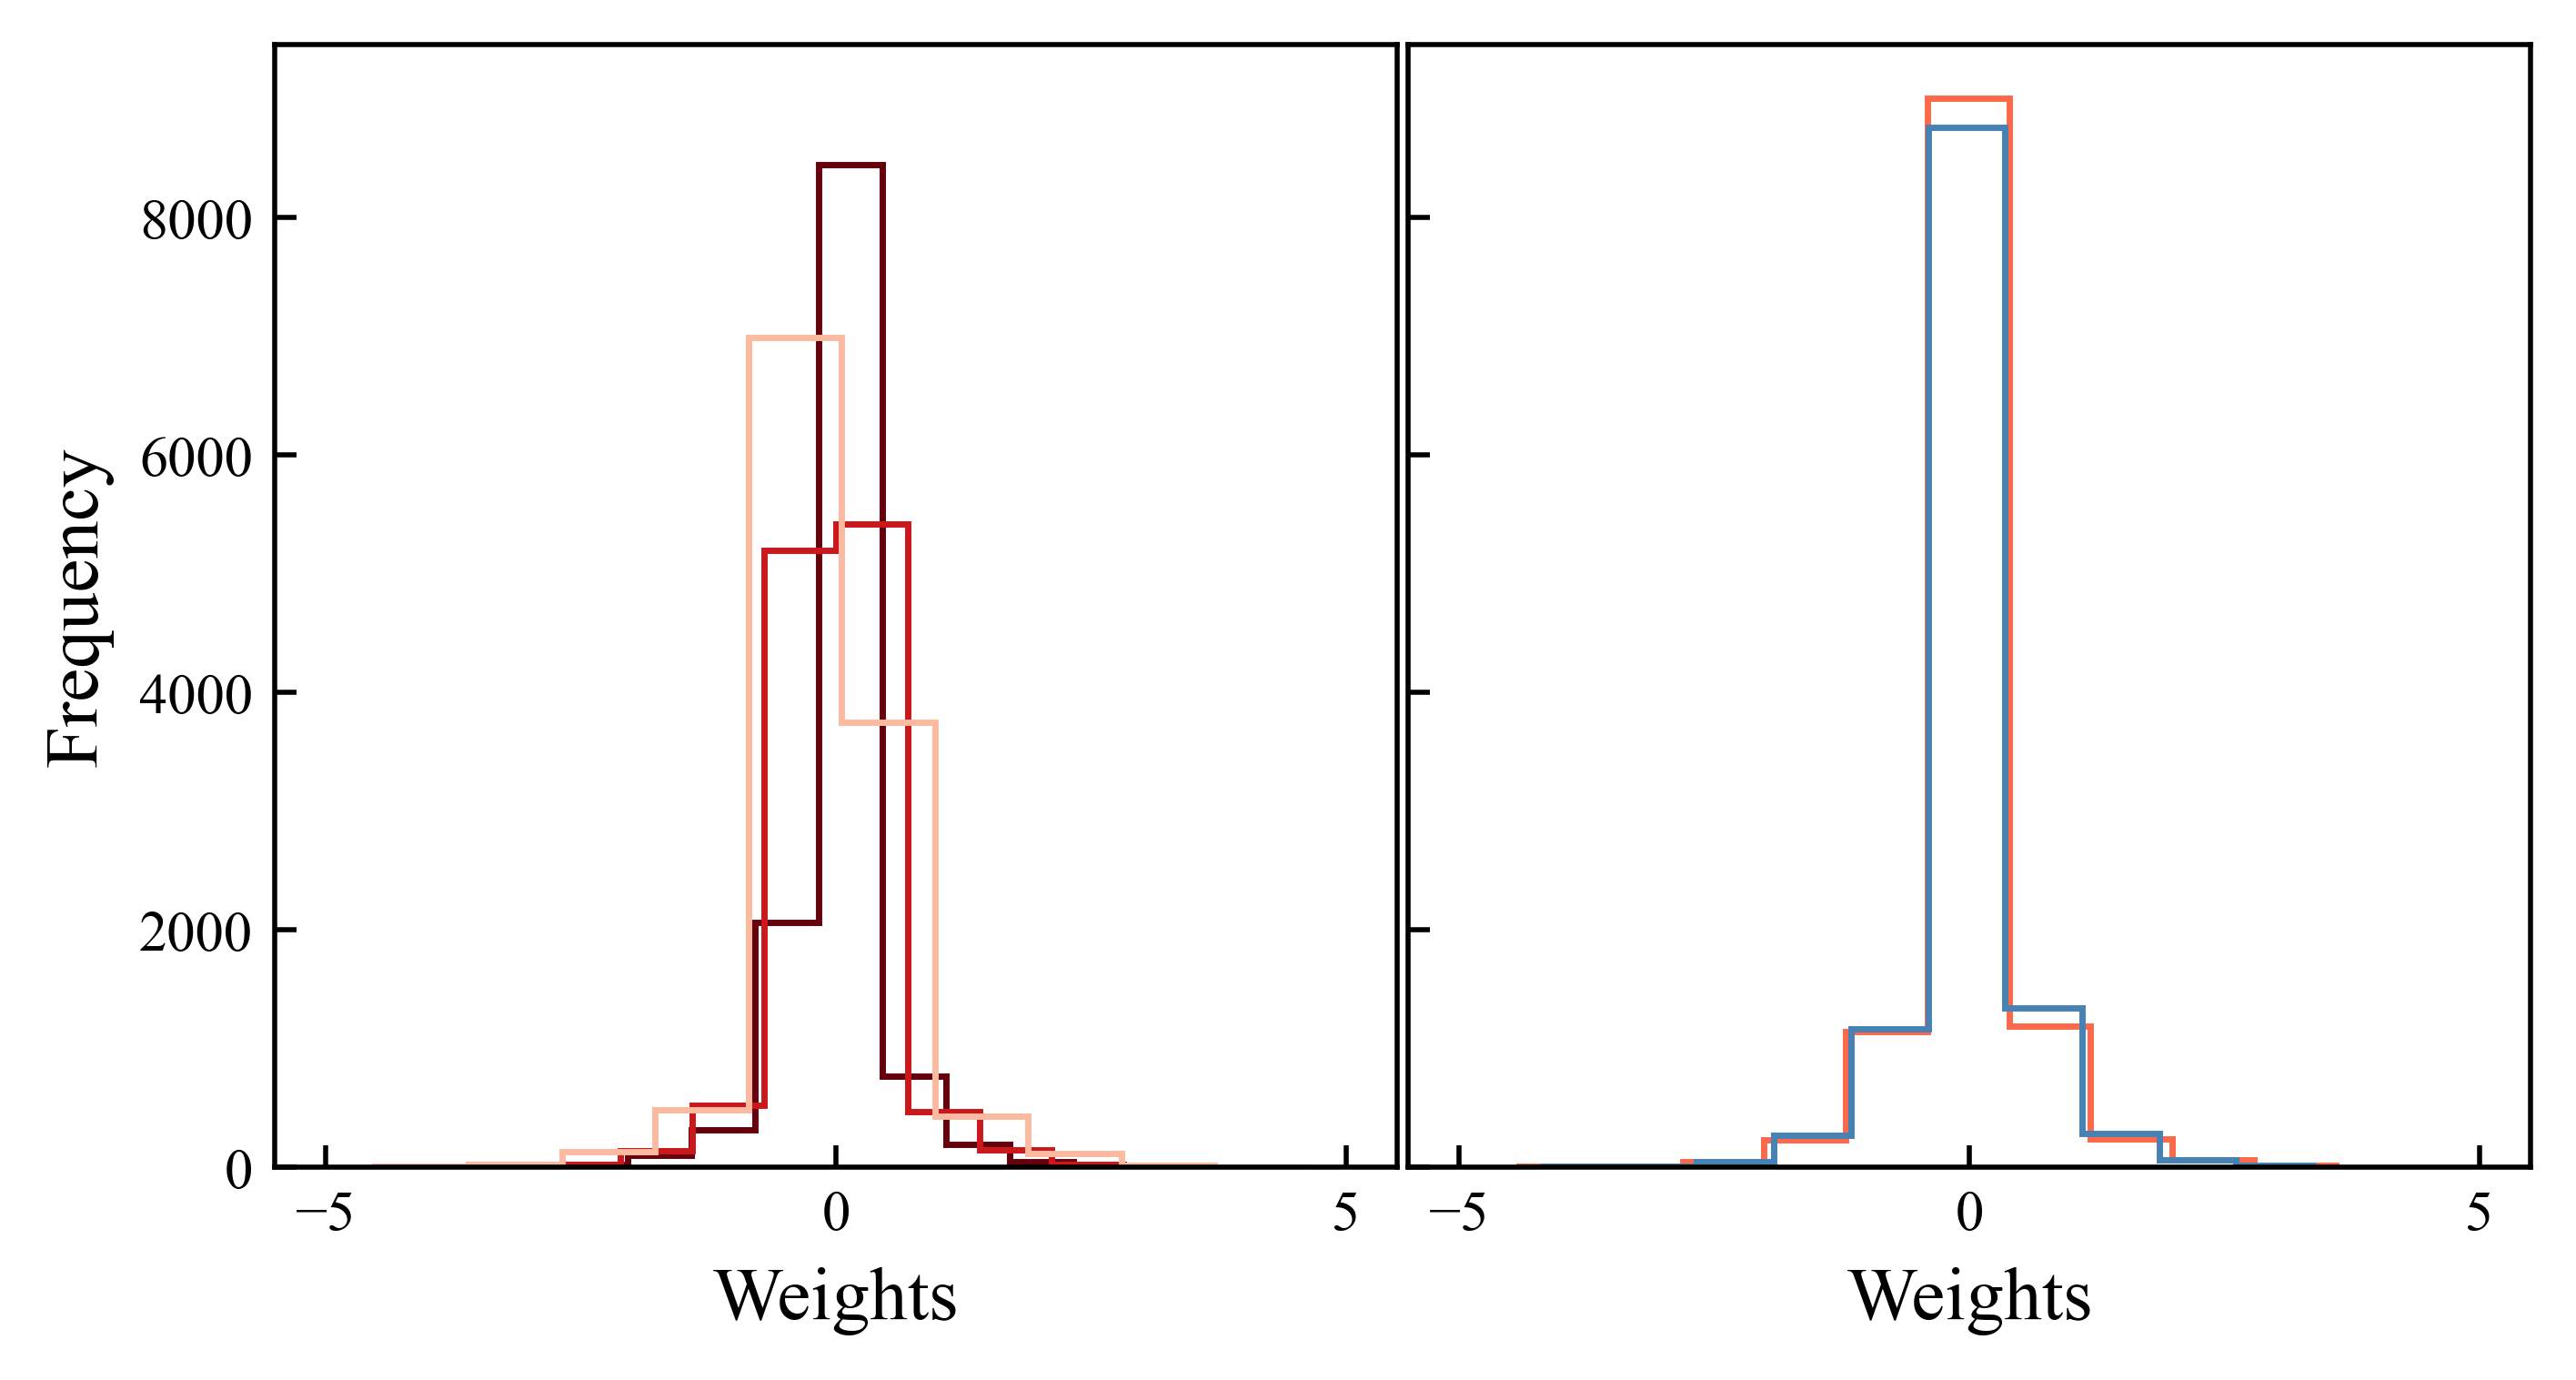

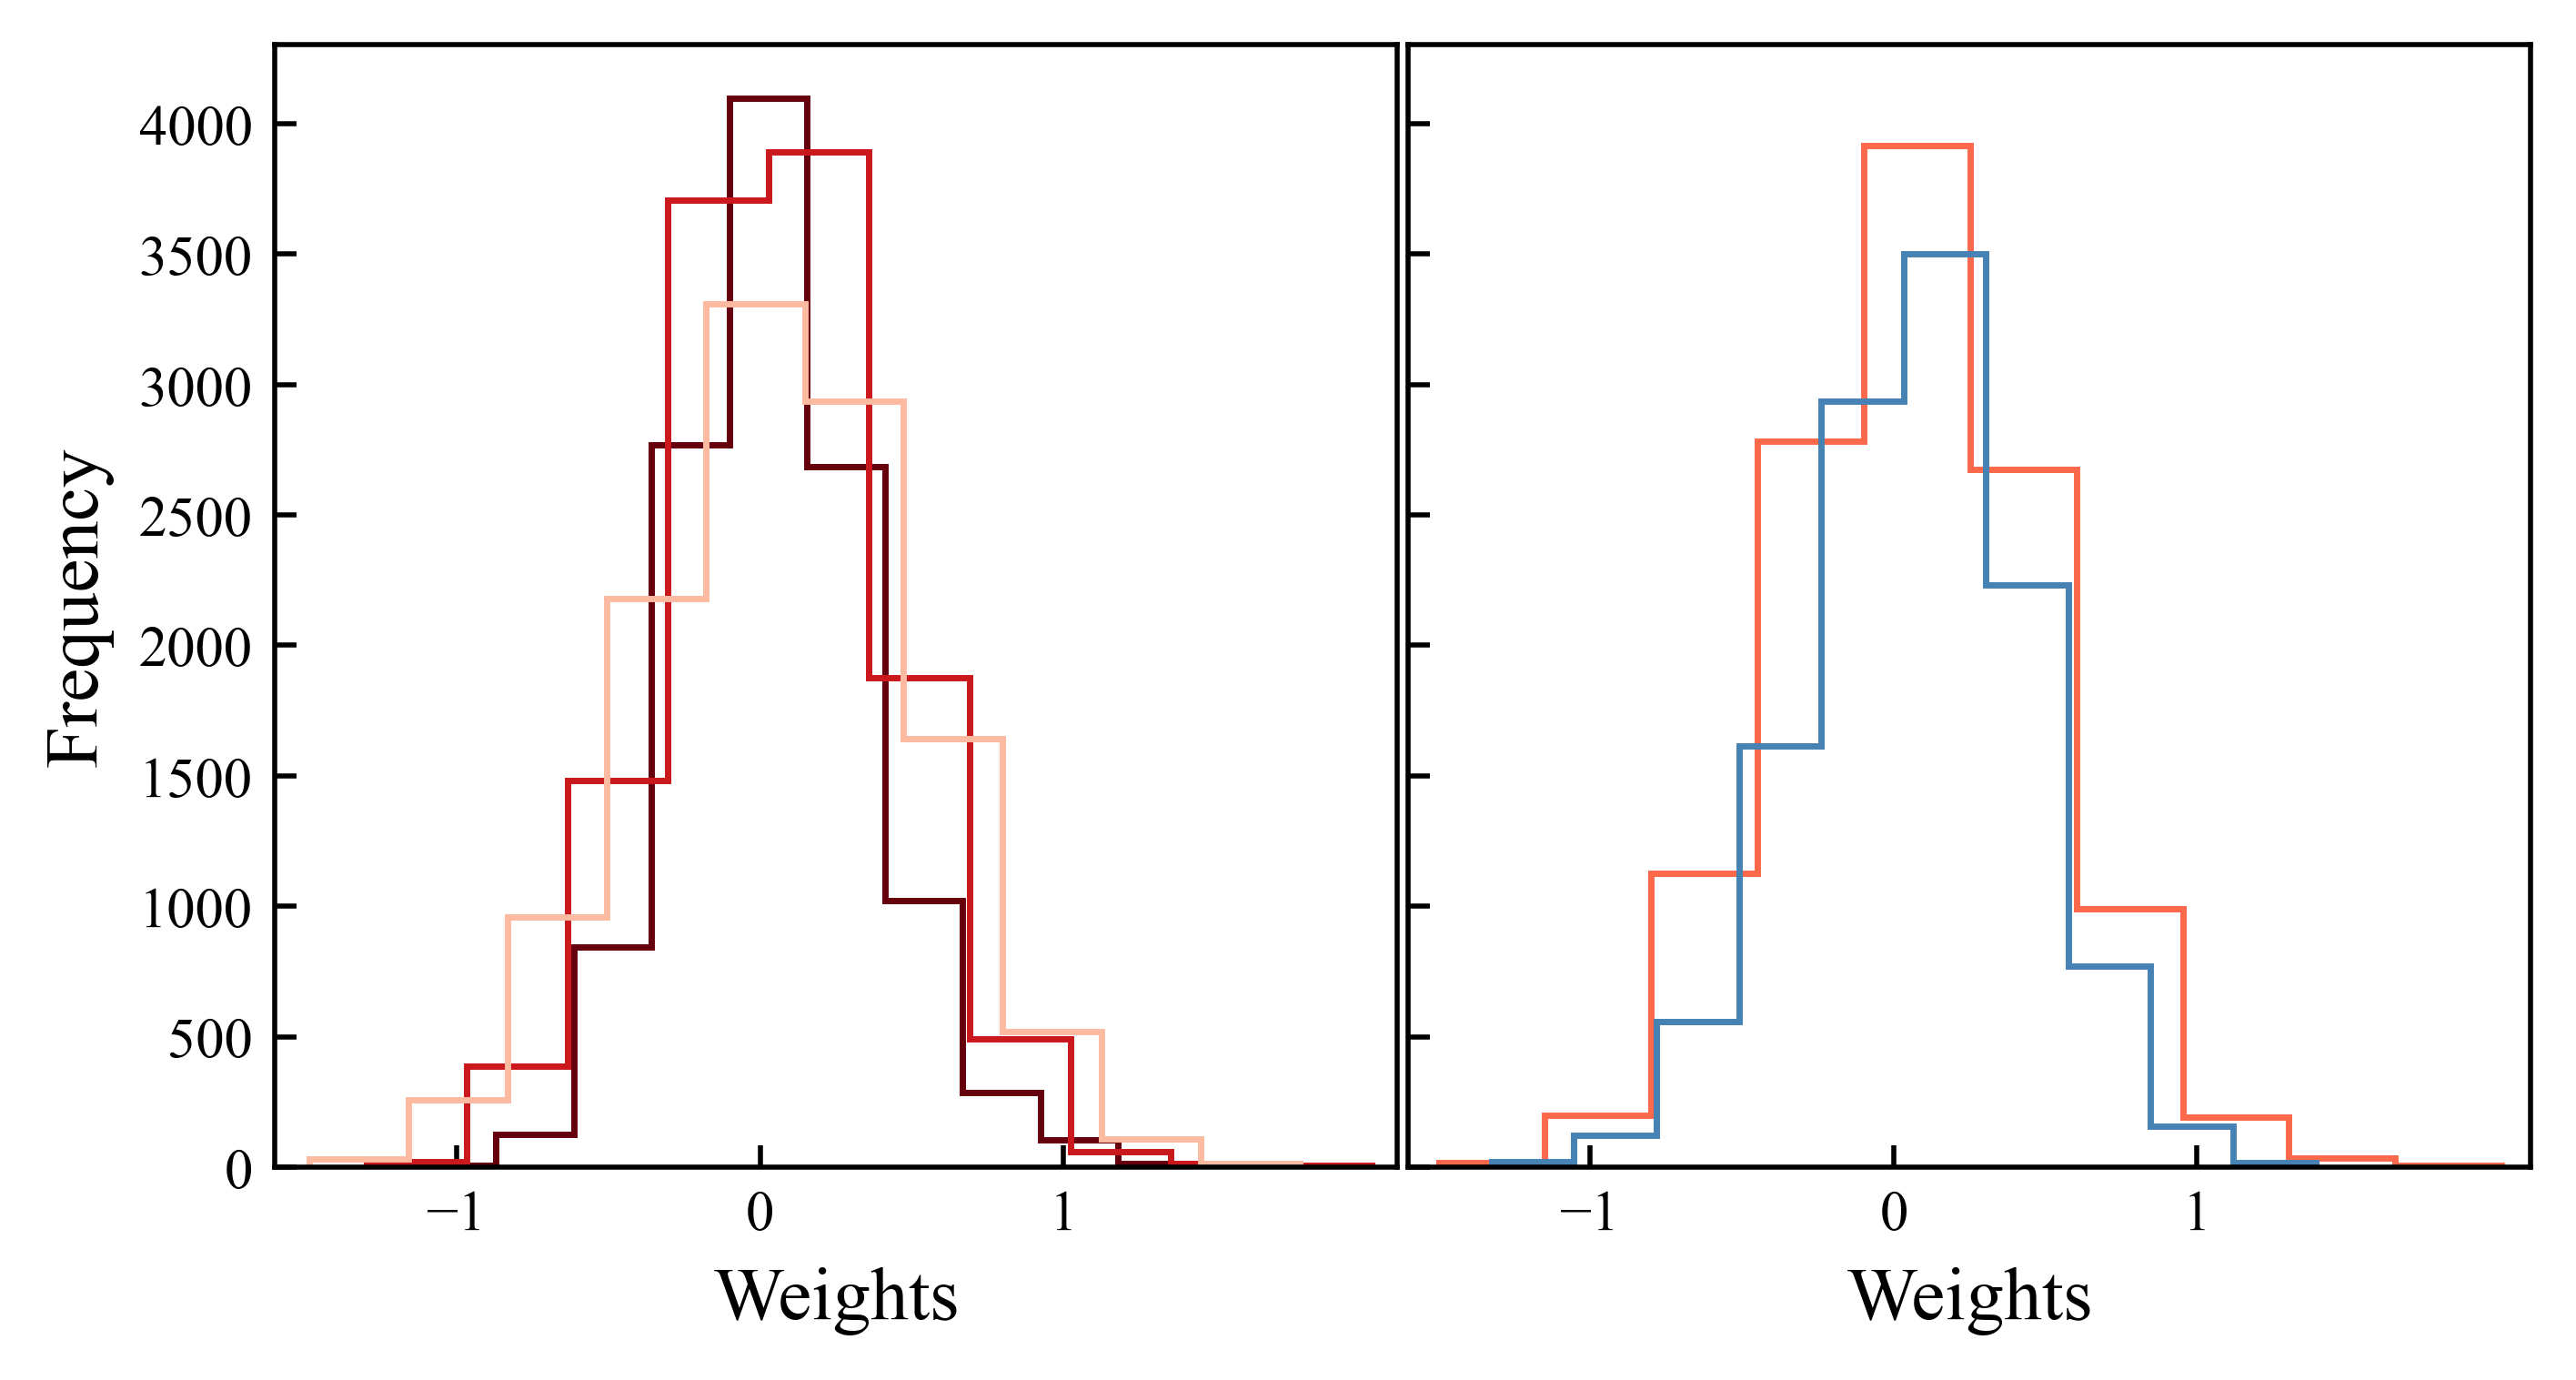

In [13]:
# ========== Histogram of weight distribution for homogenous networks ==========

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import sys
import os
import random
from matplotlib.patches import Patch


########## Loop variables ##########
vrest = [-8.5, -12.3, -17, -22]
slope = [14.44, 10.68, 8.65, 7.18]
slope_qif = [10.74]
all_slopes = [14.44, 10.68, 10.74, 8.65, 7.18]
pqif_number = [0, 0.25, 0.5, 0.75, 1]
pqif_homogenous = [0, 1]

dynamics = ['oscillations', 'sequences']
# dynamics = ['oscillations']

# seed_number = [i for i in range(0, 1)] # Only use one seed for this
seed_number = [random.randint(1, 49)]
seed_number = [2] 
print(f"Used seed {seed_number}")

rows = []

log = False
bins = 10

########## Figure loop ##########
for dyn in dynamics:

    simulation_number = [i for i in range(1,5)] if dyn == 'oscillations' else [i for i in range(9,13)]

    figname = f"{dyn}_homogenous_histo_weights_filtered.svg"

    #### Create figure and axes

    fig, (ax1, ax2) = plt.subplots(
        nrows=1, ncols=2,
        # figsize=(10,4),  # TODO review
        sharey=True
    )

    fig.subplots_adjust(
    wspace=0.01
)


    #### Figure control flow

    for sim, vr, f in zip(simulation_number, vrest, slope):
        for pqif in pqif_homogenous:
            for seed in seed_number:

                #### Take out values to plot

                df_filtered = wDF[(wDF['dynamic'] == dyn) & (wDF['simulation'] == sim) & (wDF['pqif'] == pqif) & (wDF['seed'] == seed)]  # Current row of dataframe with metadata

                ID = df_filtered['simulationID'].item()  # Simulation ID

                # current_weights_noflatten = weights_dict[ID].to_numpy()  # Weight array not flattened
                # current_weights = current_weights_noflatten.flatten()

                current_weights = weights_filtered_dict[ID]

                std = current_weights.std()
                mn = current_weights.mean()

                #### Color control flow
                if pqif == 1:
                    colors = 'steelblue'
                else:
                    colors = color_map_vrest[vr]

                if pqif == 0 and f in [14.44, 10.68, 7.18]:  # Left
                # if pqif == 0 and f in slope:  # Left
                # if pqif == 0 and f in [14.44]:  # Left

                    if sim == simulation_number[0]:  # LIF header in legend
                        label = f"LIF\n$F'$={f}"
                    else:
                        label = f"$F'$={f}"

                    ax1.hist(current_weights, bins=bins, log=log, color=colors, alpha=1, linewidth=1, histtype='step', label=label)

                    
                elif f == 8.65:  # Right
                # elif pqif == 1 and sim == simulation_number[2]:
                # if sim == simulation_number[2]:
                    if pqif == 0:
                        label = f"LIF\n$F'$={f}"
                    else:
                        label = 'QIF'

                    ax2.hist(current_weights, bins=bins, log=log, color=colors, alpha=1, linewidth=1, histtype='step', label=label)


                else:  # Ignore others
                    continue


    #### Shared formatting

    if dyn == 'oscillations':
        tick_positions = [-5, 0, 5]
        xlim = (-5.5, 5.5)
    elif dyn == 'sequences':
        tick_positions = [-1, 0, 1]
        xlim = (-1.6, 2.1)

    for ax in (ax1, ax2):
        ax.set_xlabel("Weights")
        ax.set_xticks(tick_positions)
        ax.set_xlim(xlim)
        ax.set_box_aspect(1)
    ax1.set_ylabel("Frequency")


    
    #### Save
    # full_path = os.path.join(figure_folder, figname)
    # plt.savefig(full_path, format="svg")

    # plt.tight_layout()
    plt.show()



# 2

In [8]:
wDF

,simulationID,dynamic,simulation,vrest,slope,pqif,seed,std,mean,mean_filtered,std_filtered
0,oscillations_1_0_0,oscillations,1,-8.5,14.44,0.0,0,0.255446,-0.000068,-0.000227,0.467568
1,oscillations_1_0_1,oscillations,1,-8.5,14.44,0.0,1,0.233008,0.000042,0.000142,0.426534
2,oscillations_1_0_2,oscillations,1,-8.5,14.44,0.0,2,0.233865,-0.000029,-0.000096,0.428067
3,oscillations_1_0_3,oscillations,1,-8.5,14.44,0.0,3,0.239014,-0.000076,-0.000255,0.437272
4,oscillations_1_0_4,oscillations,1,-8.5,14.44,0.0,4,0.234006,-0.000066,-0.000220,0.428056
...,...,...,...,...,...,...,...,...,...,...,...
1995,sequences_12_1_45,sequences,12,NaN,10.74,1.0,45,0.213726,0.021462,0.071947,0.386649
1996,sequences_12_1_46,sequences,12,NaN,10.74,1.0,46,0.211047,0.021321,0.071408,0.381578
1997,sequences_12_1_47,sequences,12,NaN,10.74,1.0,47,0.218655,0.021589,0.072336,0.395630
1998,sequences_12_1_48,sequences,12,NaN,10.74,1.0,48,0.197260,0.021970,0.073626,0.355804


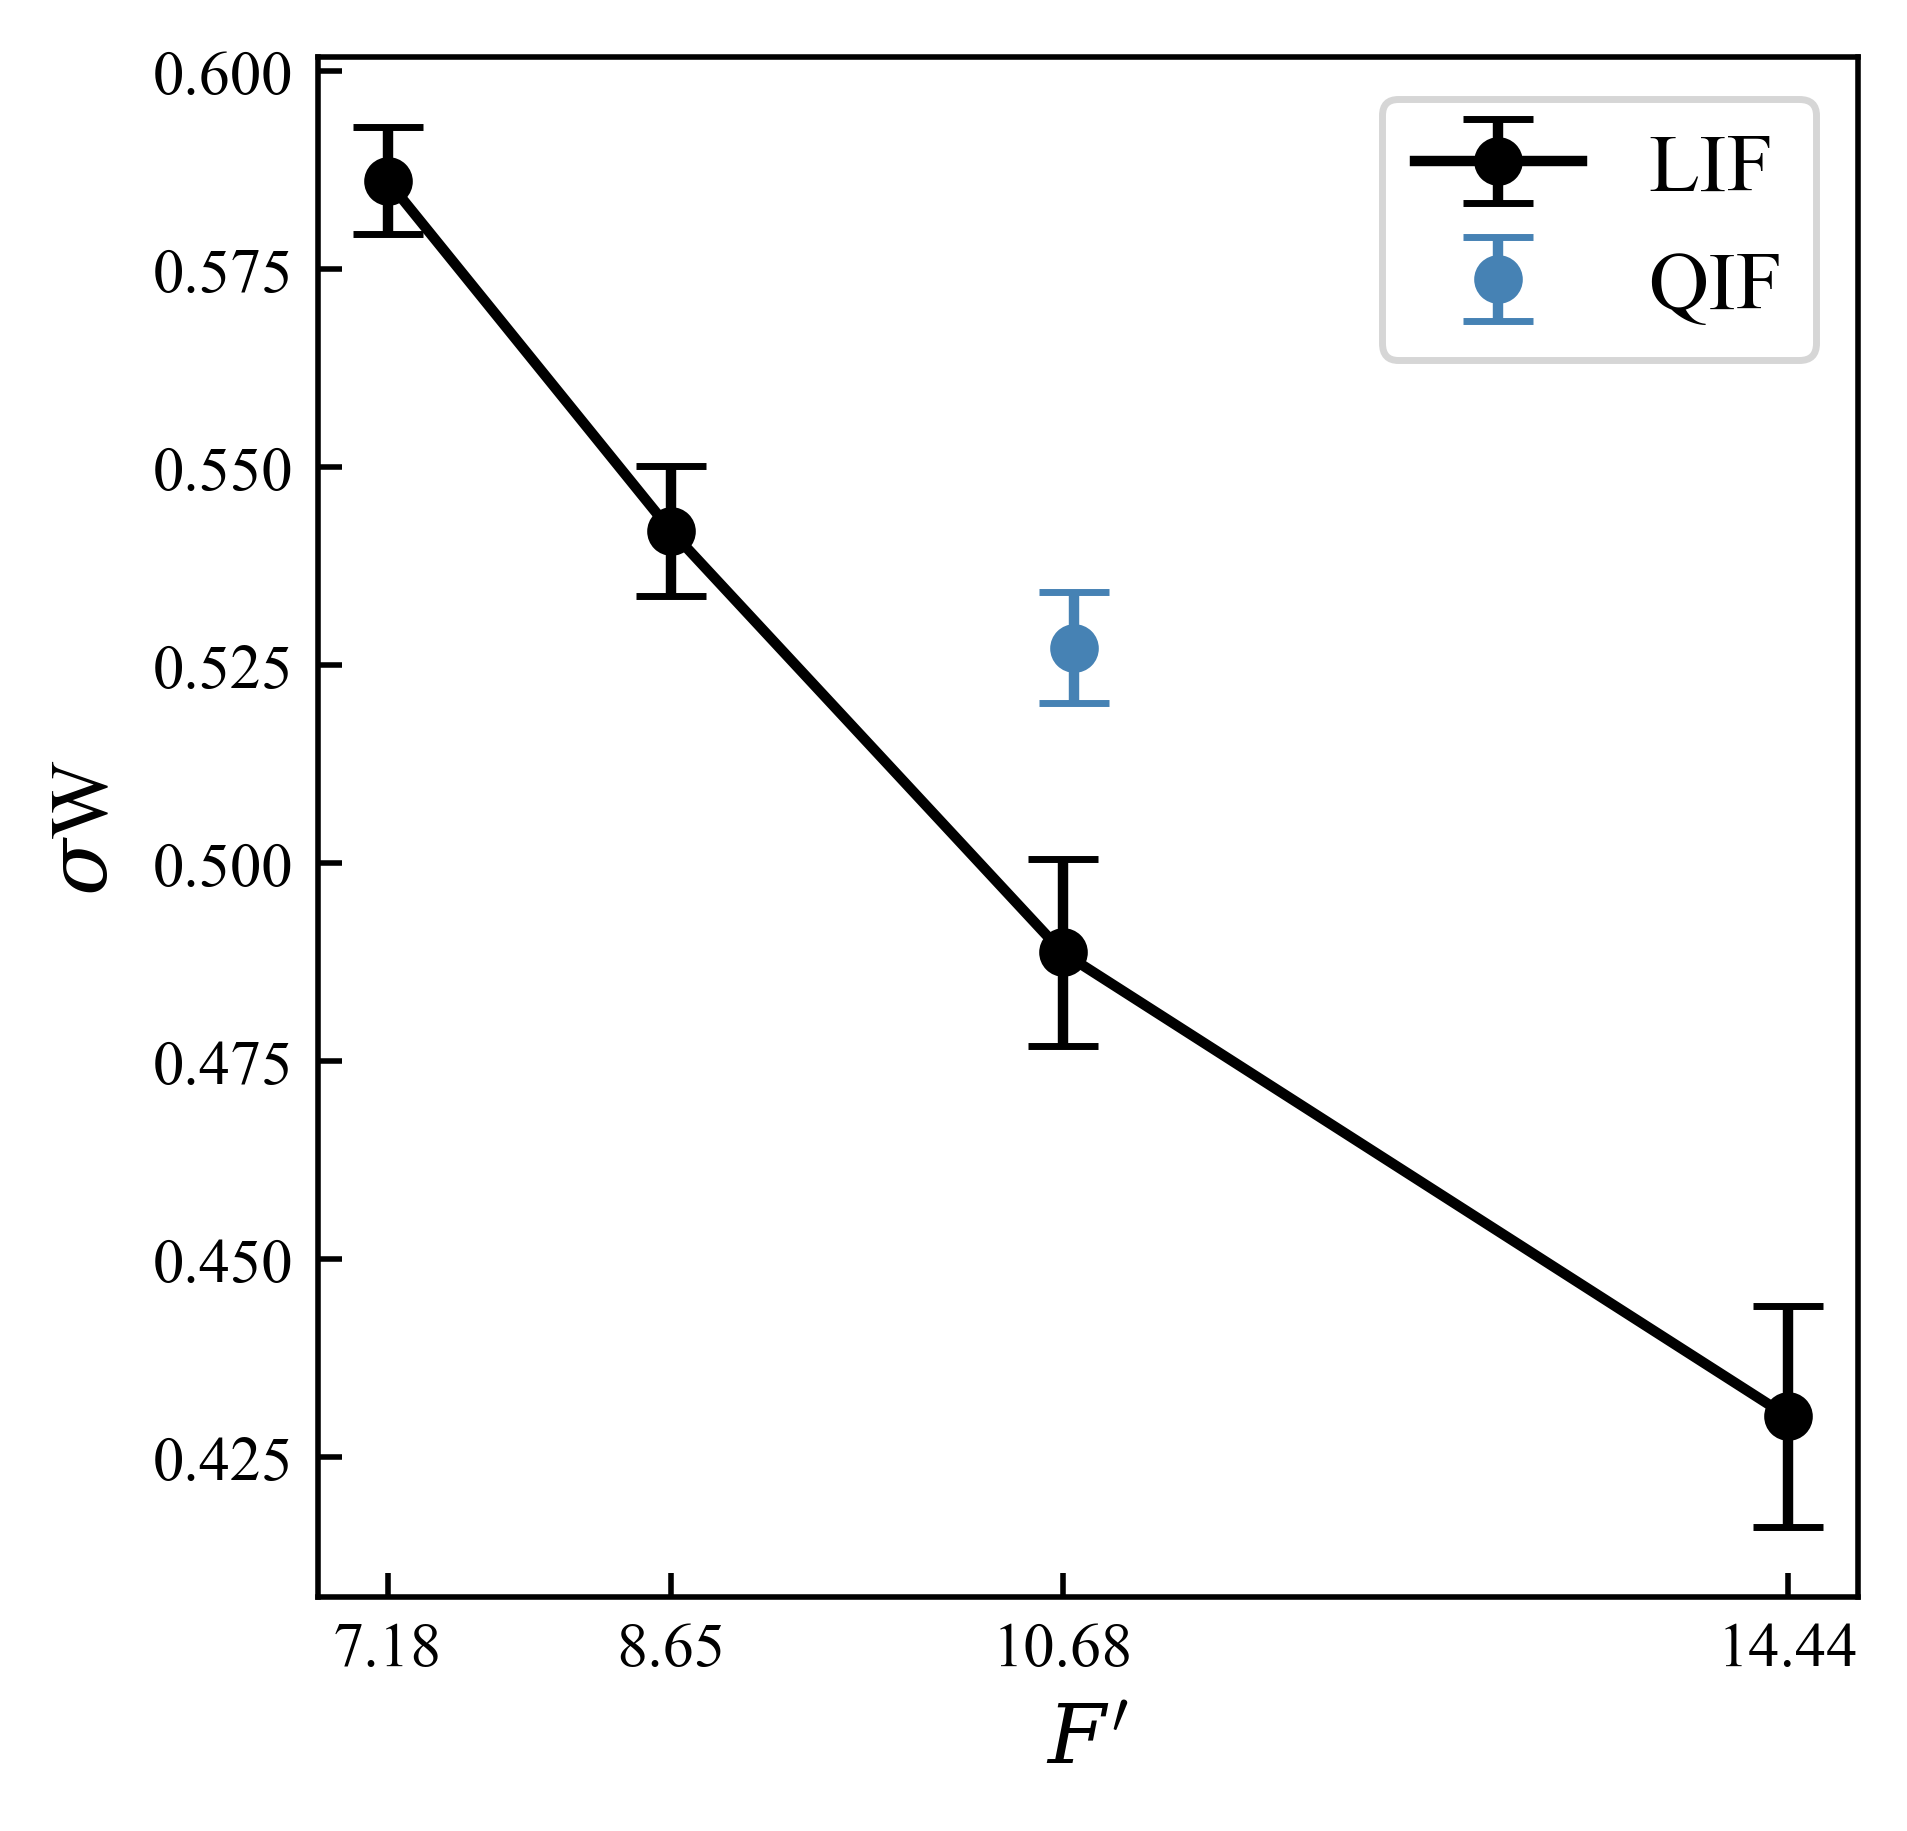

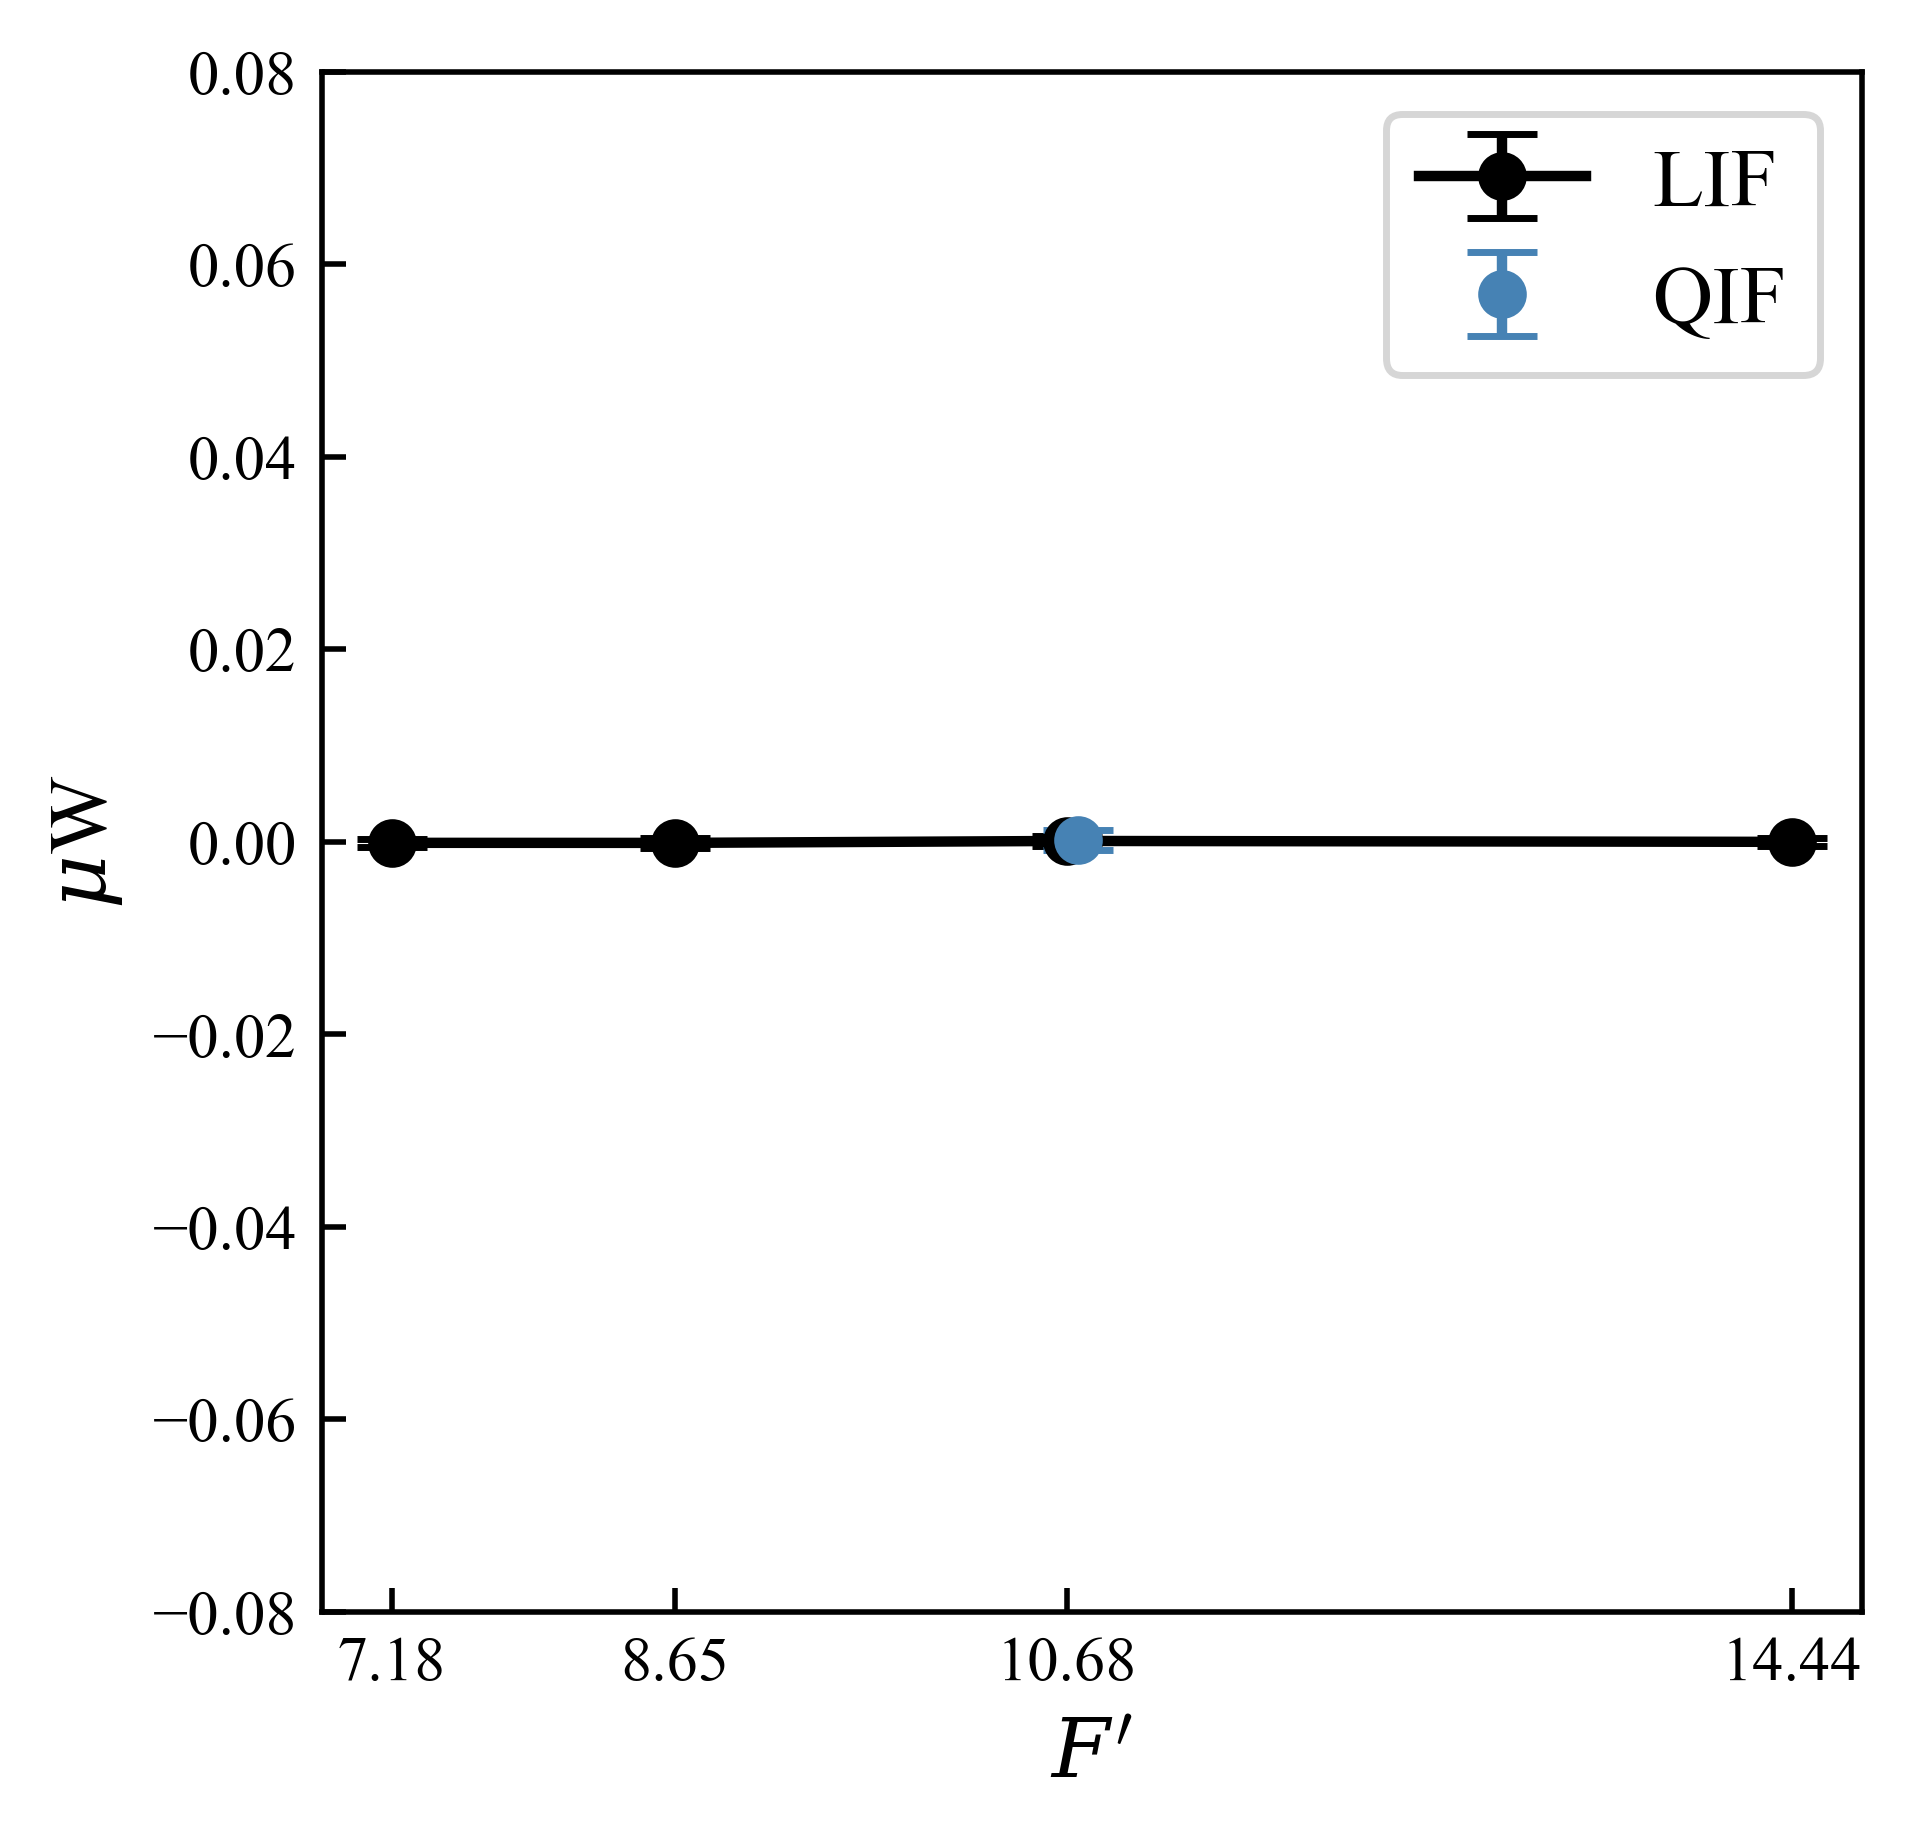

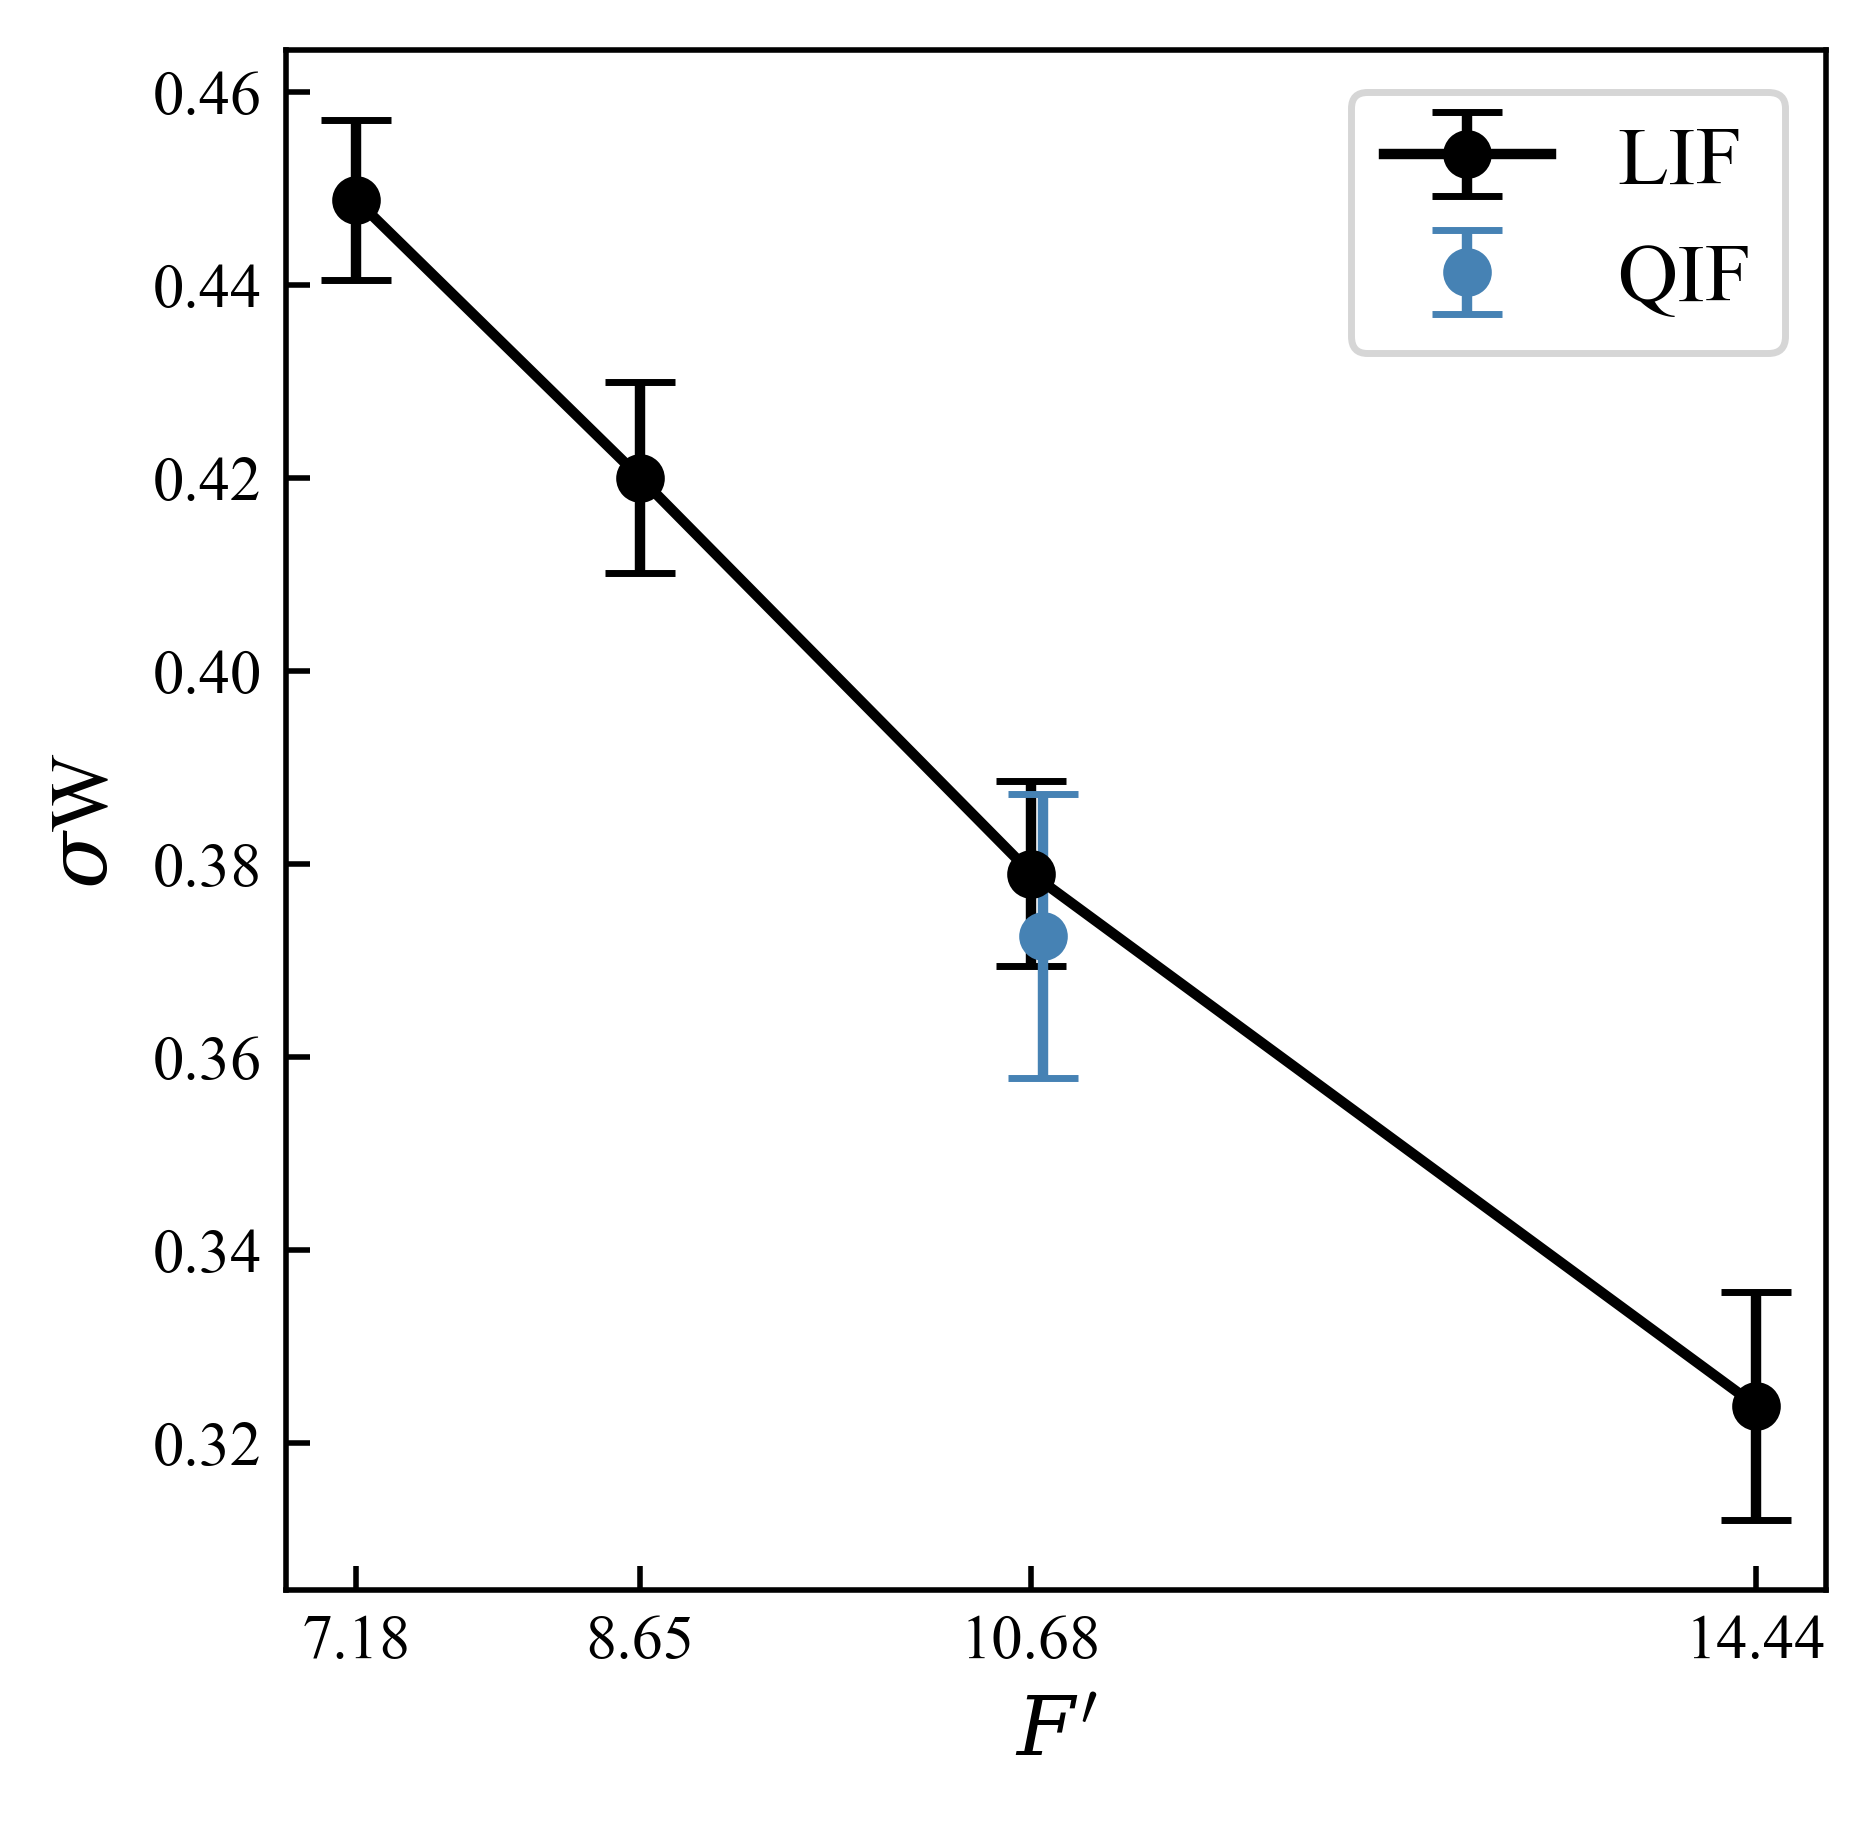

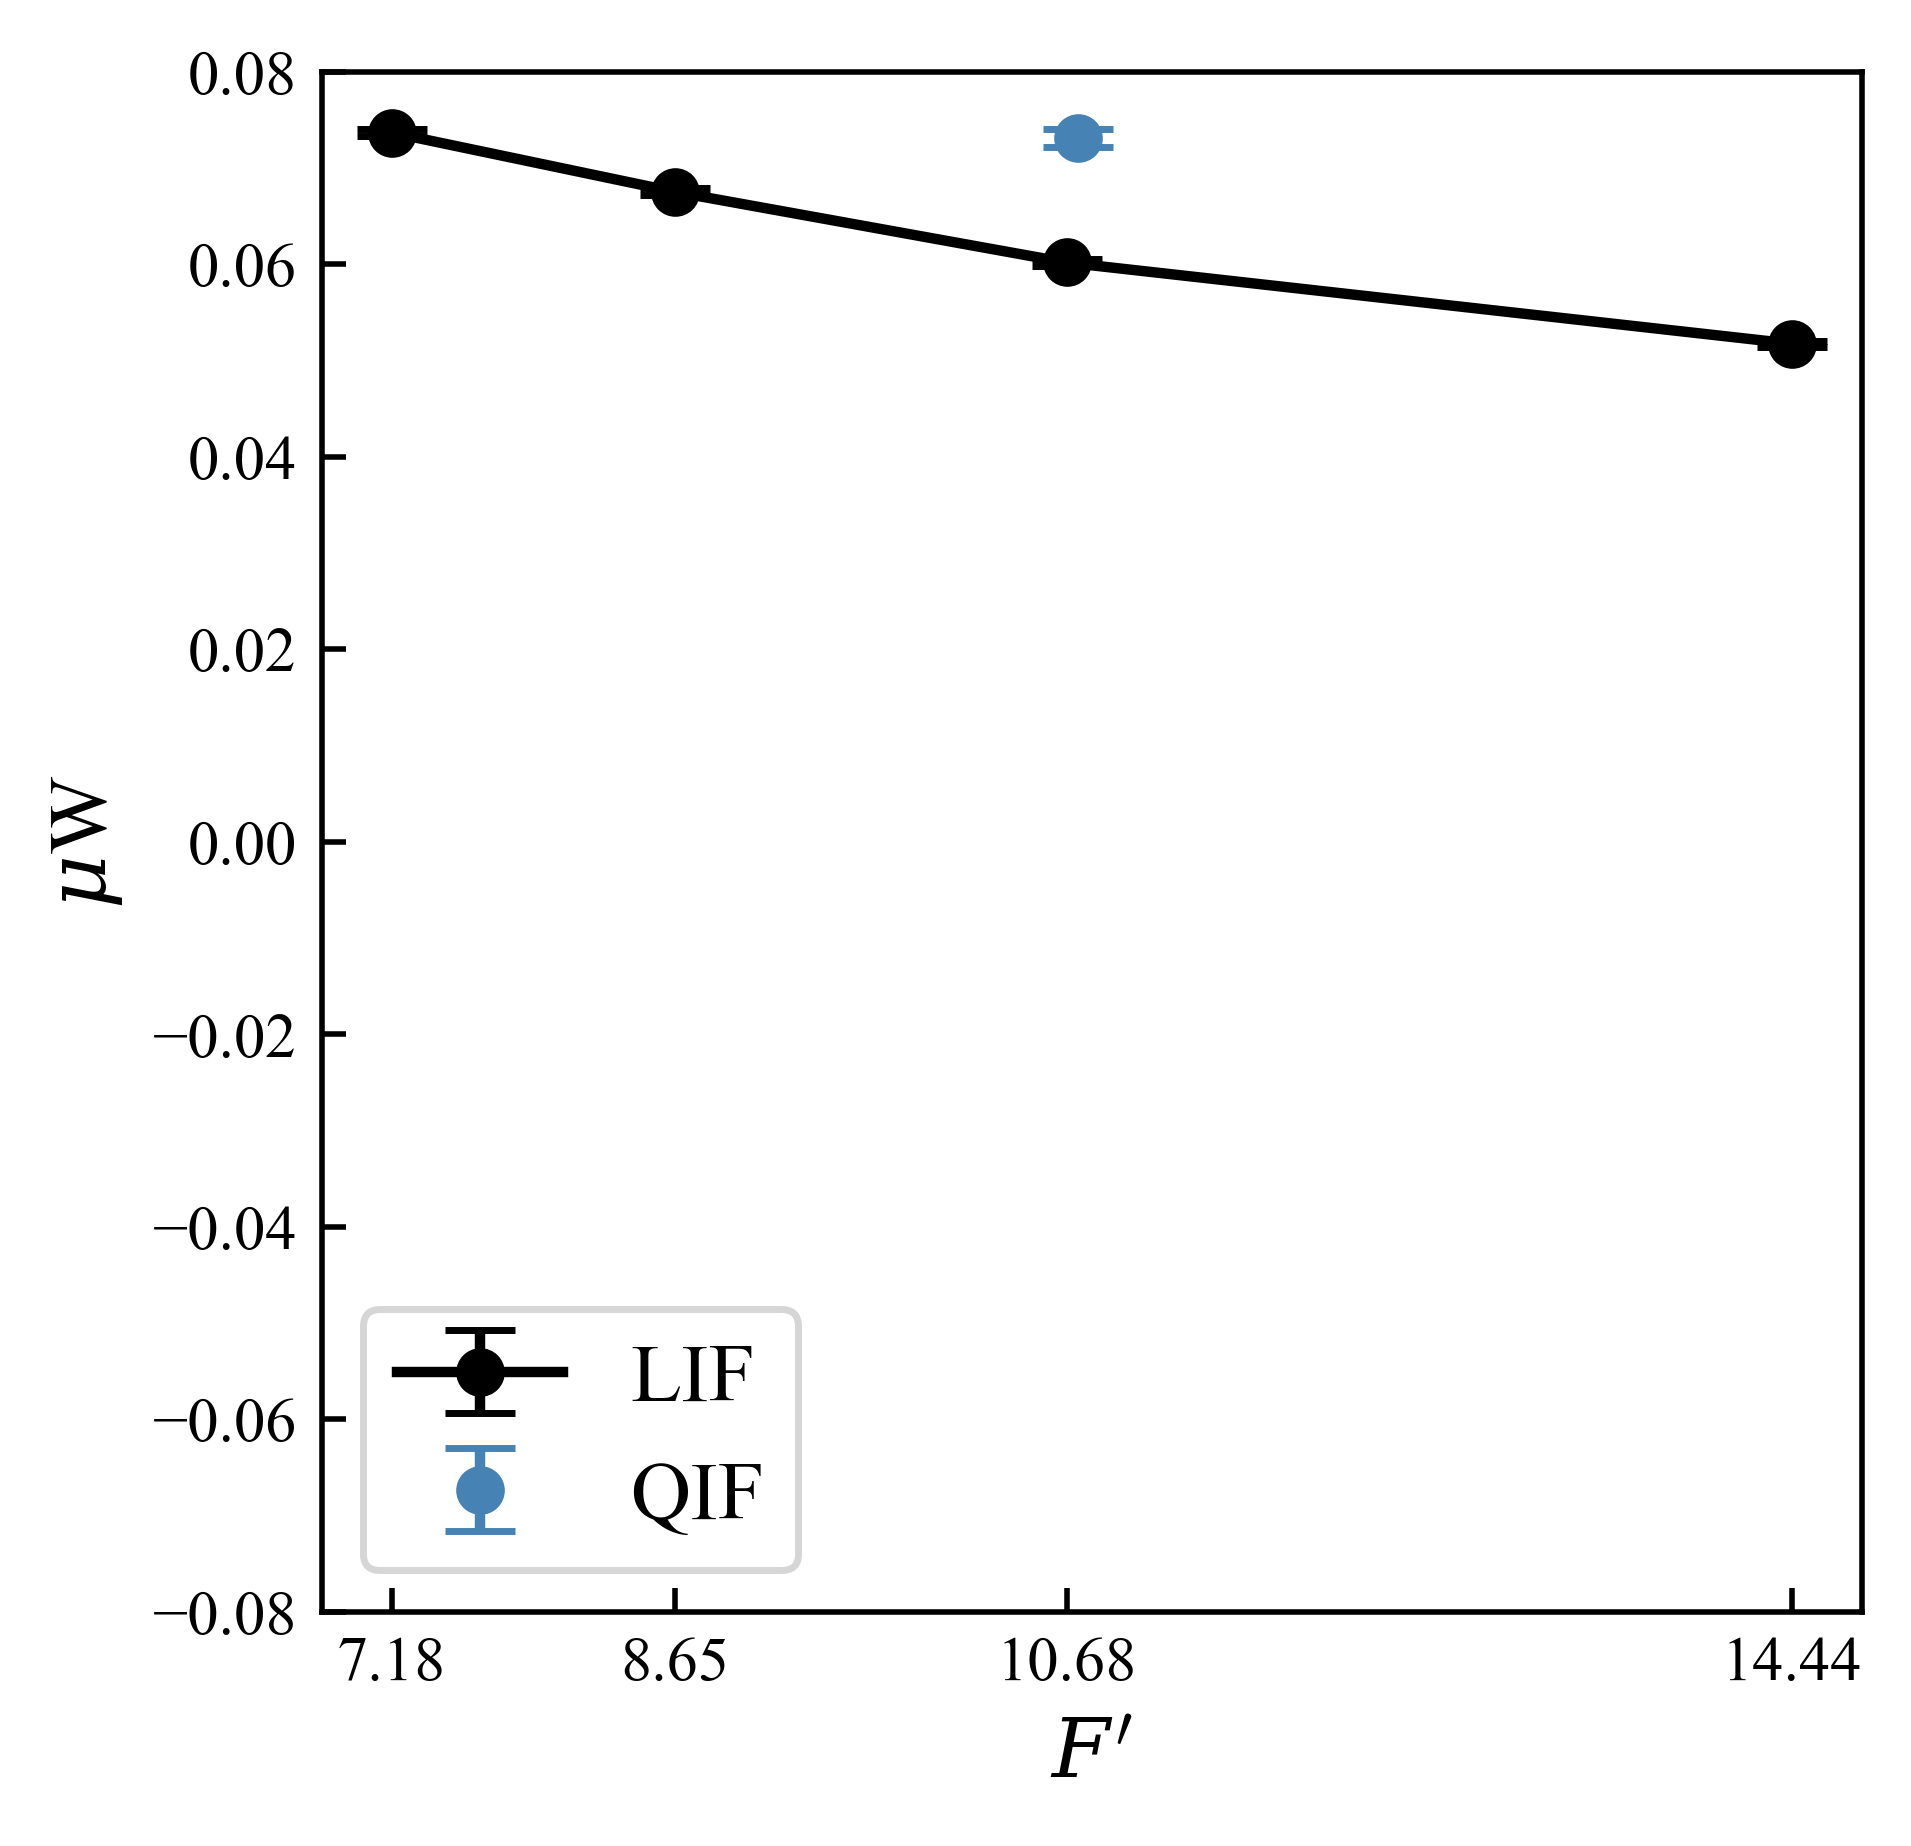

In [21]:
# ========== Standard deviation or Mean of weights vs. slope for homogenous networks ==========

import pandas as pd
import numpy as np
import matplotlib
import sys


########## Loop variables ##########
vrest = [-8.5, -12.3, -17, -22]
slope = [14.44, 10.68, 8.65, 7.18]
slope_qif = 10.74
all_slopes = [14.44, 10.68, 10.74, 8.65, 7.18]

pqif_number = [0, 0.25, 0.5, 0.75, 1]
pqif_homogenous = [0, 1]

dynamics = ['oscillations', 'sequences']
# dynamics = ['oscillations']
seed_number = [i for i in range(0, 50)]

# columns = ['std', 'mean']
columns = ['std_filtered', 'mean_filtered']

x_ticks = [14.44, 10.68, 8.65, 7.18]

########## Figure loop ##########

for dyn in dynamics:

    simulation_number = [i for i in range(1,5)] if dyn == 'oscillations' else [i for i in range(9,13)]

    #### Plot same figures for both STD and mean
    for c in columns:

        figname = f"{dyn}_homogenous_{c}-vs-slope_filtered.svg"
        fig, ax = plt.subplots(figsize=(6, 4))


        for pqif in pqif_homogenous:

            y = []
            yerr = []
            x = slope


            for sim, vr, f in zip(simulation_number, vrest, slope):

                # mean_filtered	std_filtered

                df_filtered = wDF[(wDF['dynamic'] == dyn) & (wDF['simulation'] == sim) & (wDF['pqif'] == pqif)]  # Current row of dataframe with metadata. Include all seeds since we want errorbars

                # Y: Mean of Y
                y_i = df_filtered[c].mean()

                # Y-error: STD of Y
                yerr_i = df_filtered[c].std()

                if pqif == 0: # For LIF: Make list across slope
                    y.append(y_i)
                    yerr.append(yerr_i)

                elif pqif == 1:  # Only one value for QIF since it is the same in each simulation
                    y = y_i
                    yerr = yerr_i

            colors = color_map_pqif[pqif]

            #### Title and labels depending on if STD or mean 

            if c == 'std_filtered':
                # title = f"$\sigma$W vs. $F'$, {dyn.capitalize()}"
                # title = rf"{dyn.capitalize()} (|w| > $\epsilon$ = {eps})"
                xlabel = f"$F'$"
                ylabel = f"$\sigma$W"

            elif c == "mean_filtered":
                # title = f"$\mu$W vs. $F'$, {dyn.capitalize()}"
                # title = f"$\mu$W vs. $F'$"
                xlabel = f"$F'$"
                ylabel = f"$\mu$W"
                ax.set_ylim(-0.08, 0.08)

            #### Plot values on ax

            if pqif == 0:
                label = 'LIF'
                ax.errorbar(x, y, yerr, fmt='o-', capsize=5, color=colors, label=label)

            elif pqif == 1:
                label = 'QIF'
                ax.errorbar(slope_qif, y, yerr, fmt='o', capsize=5, color=colors, label=label)

        # ax.set_title(rf"{dyn.capitalize()} (|w| > $\epsilon$ = {eps})")
        ax.set_xticks(x_ticks)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.set_box_aspect(1)

        # if c == "mean":
        #     ax.set_ylim(0, 0.024)
        plt.legend()
        full_path = os.path.join(figure_folder, figname)
        plt.savefig(full_path, format="svg")
        plt.show()



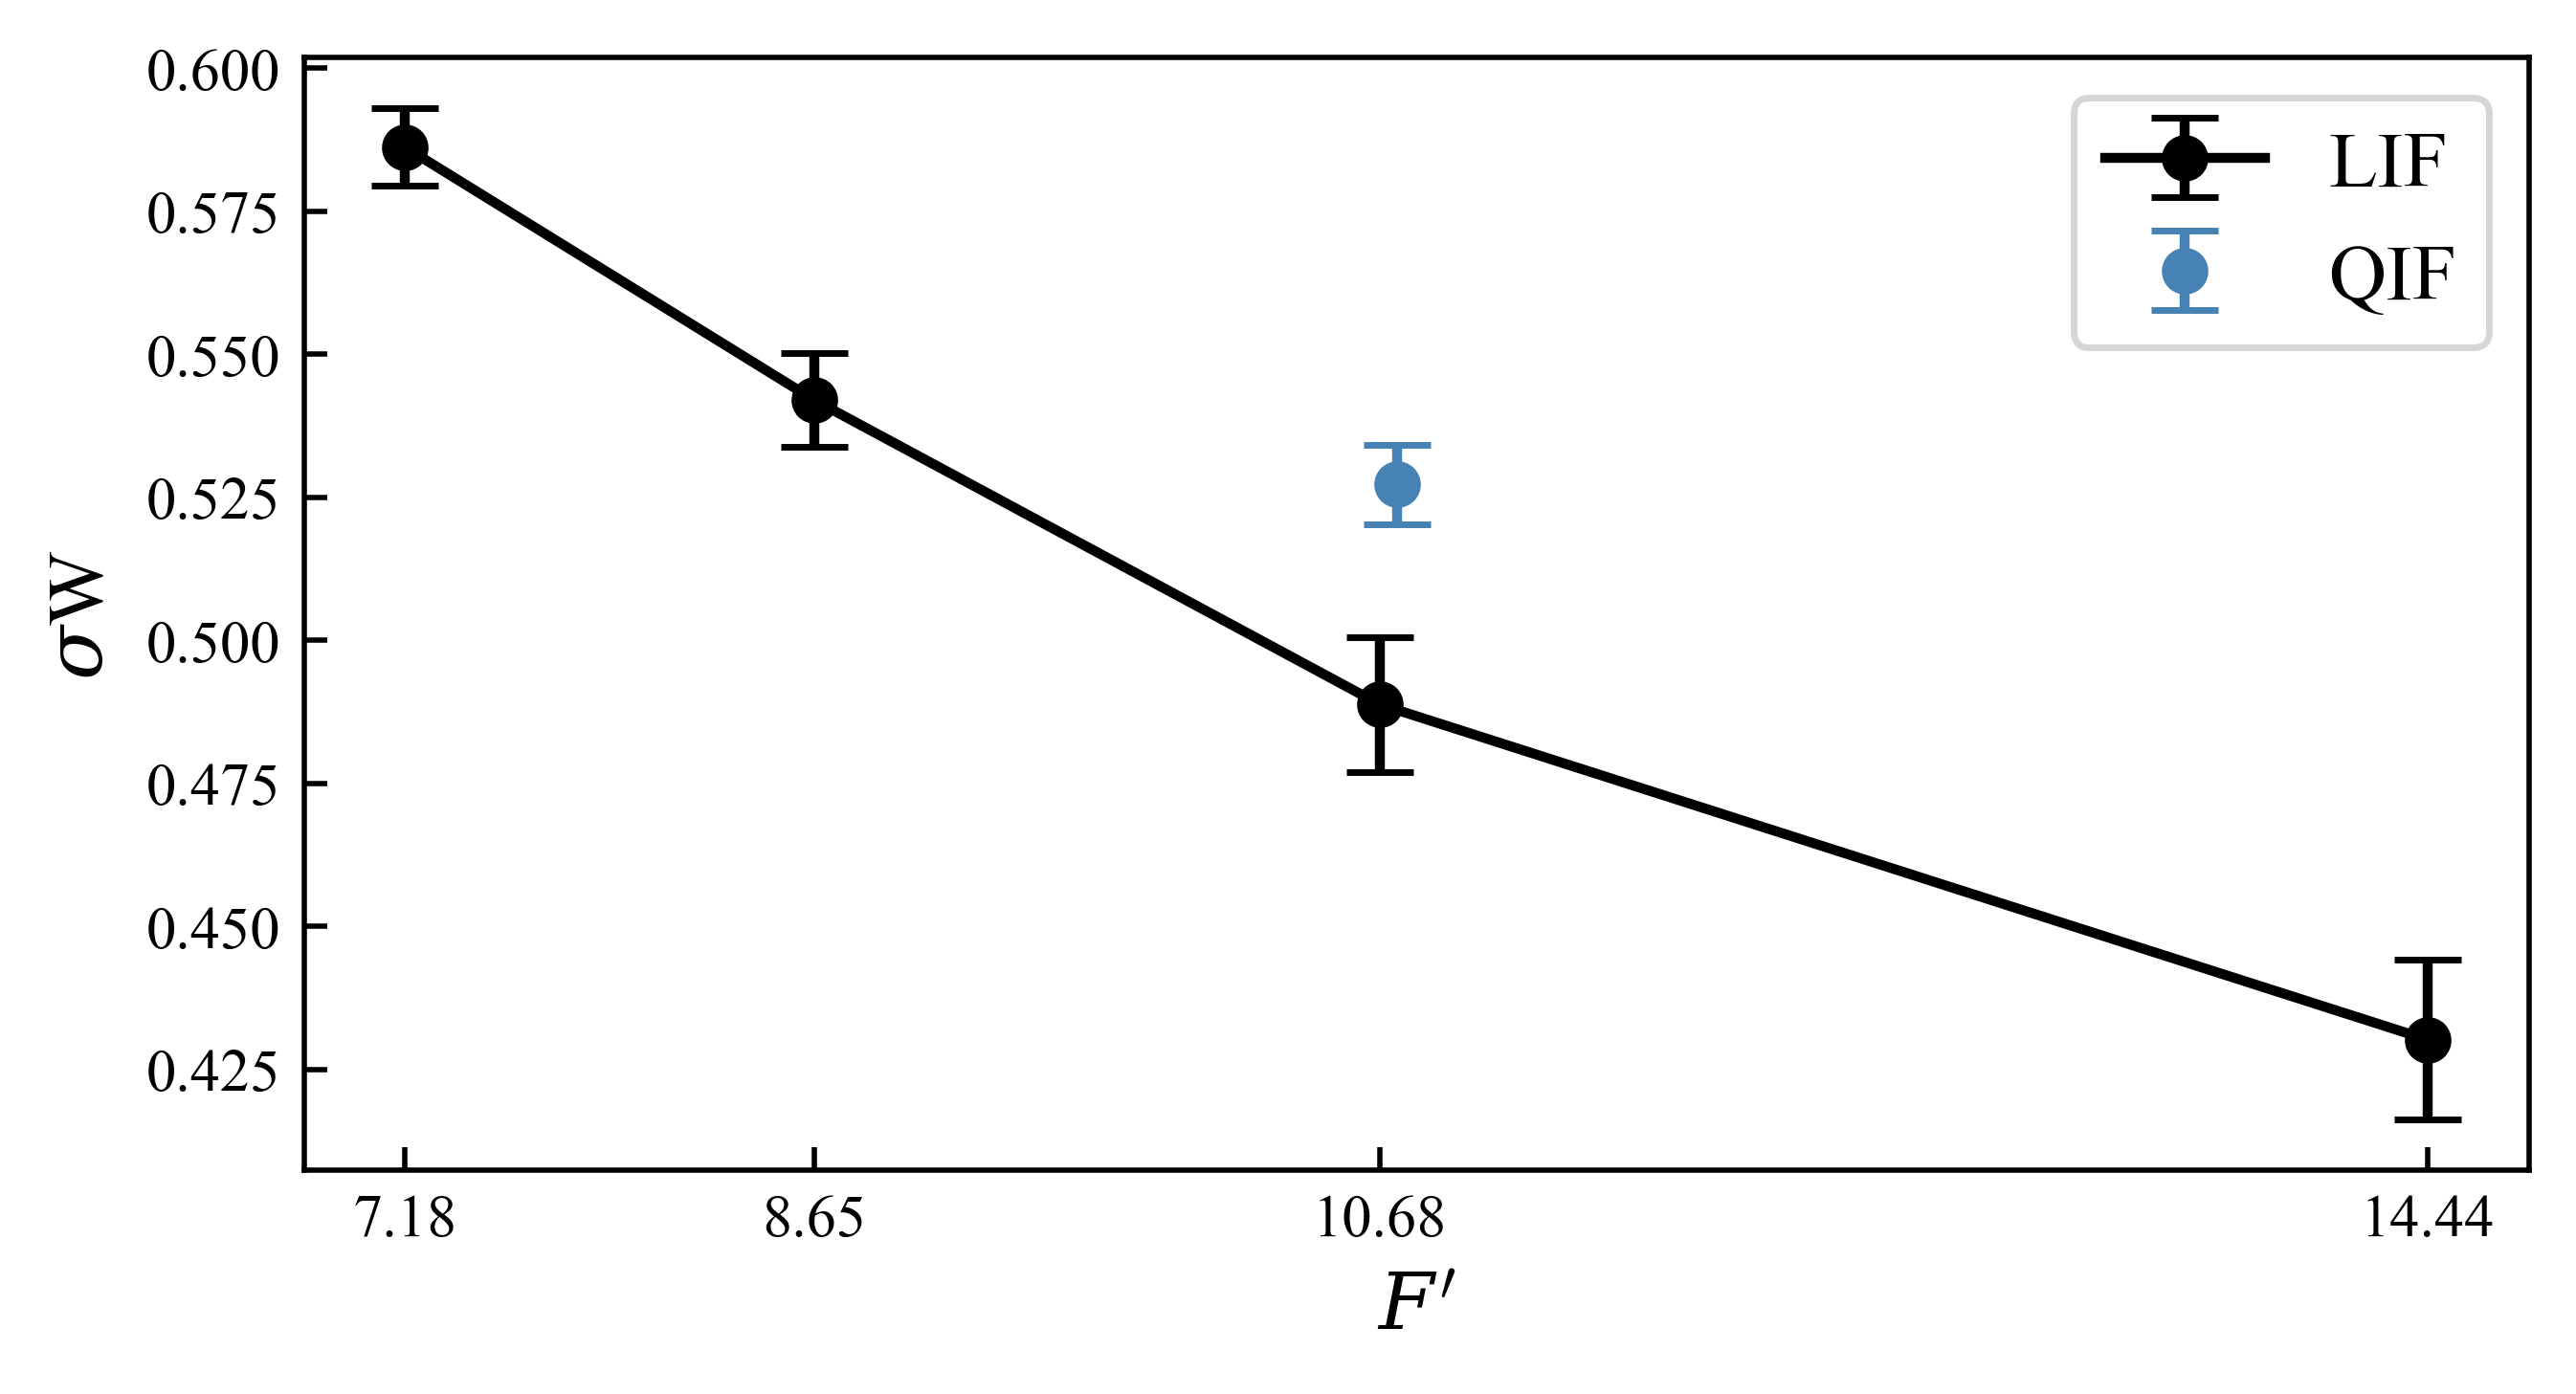

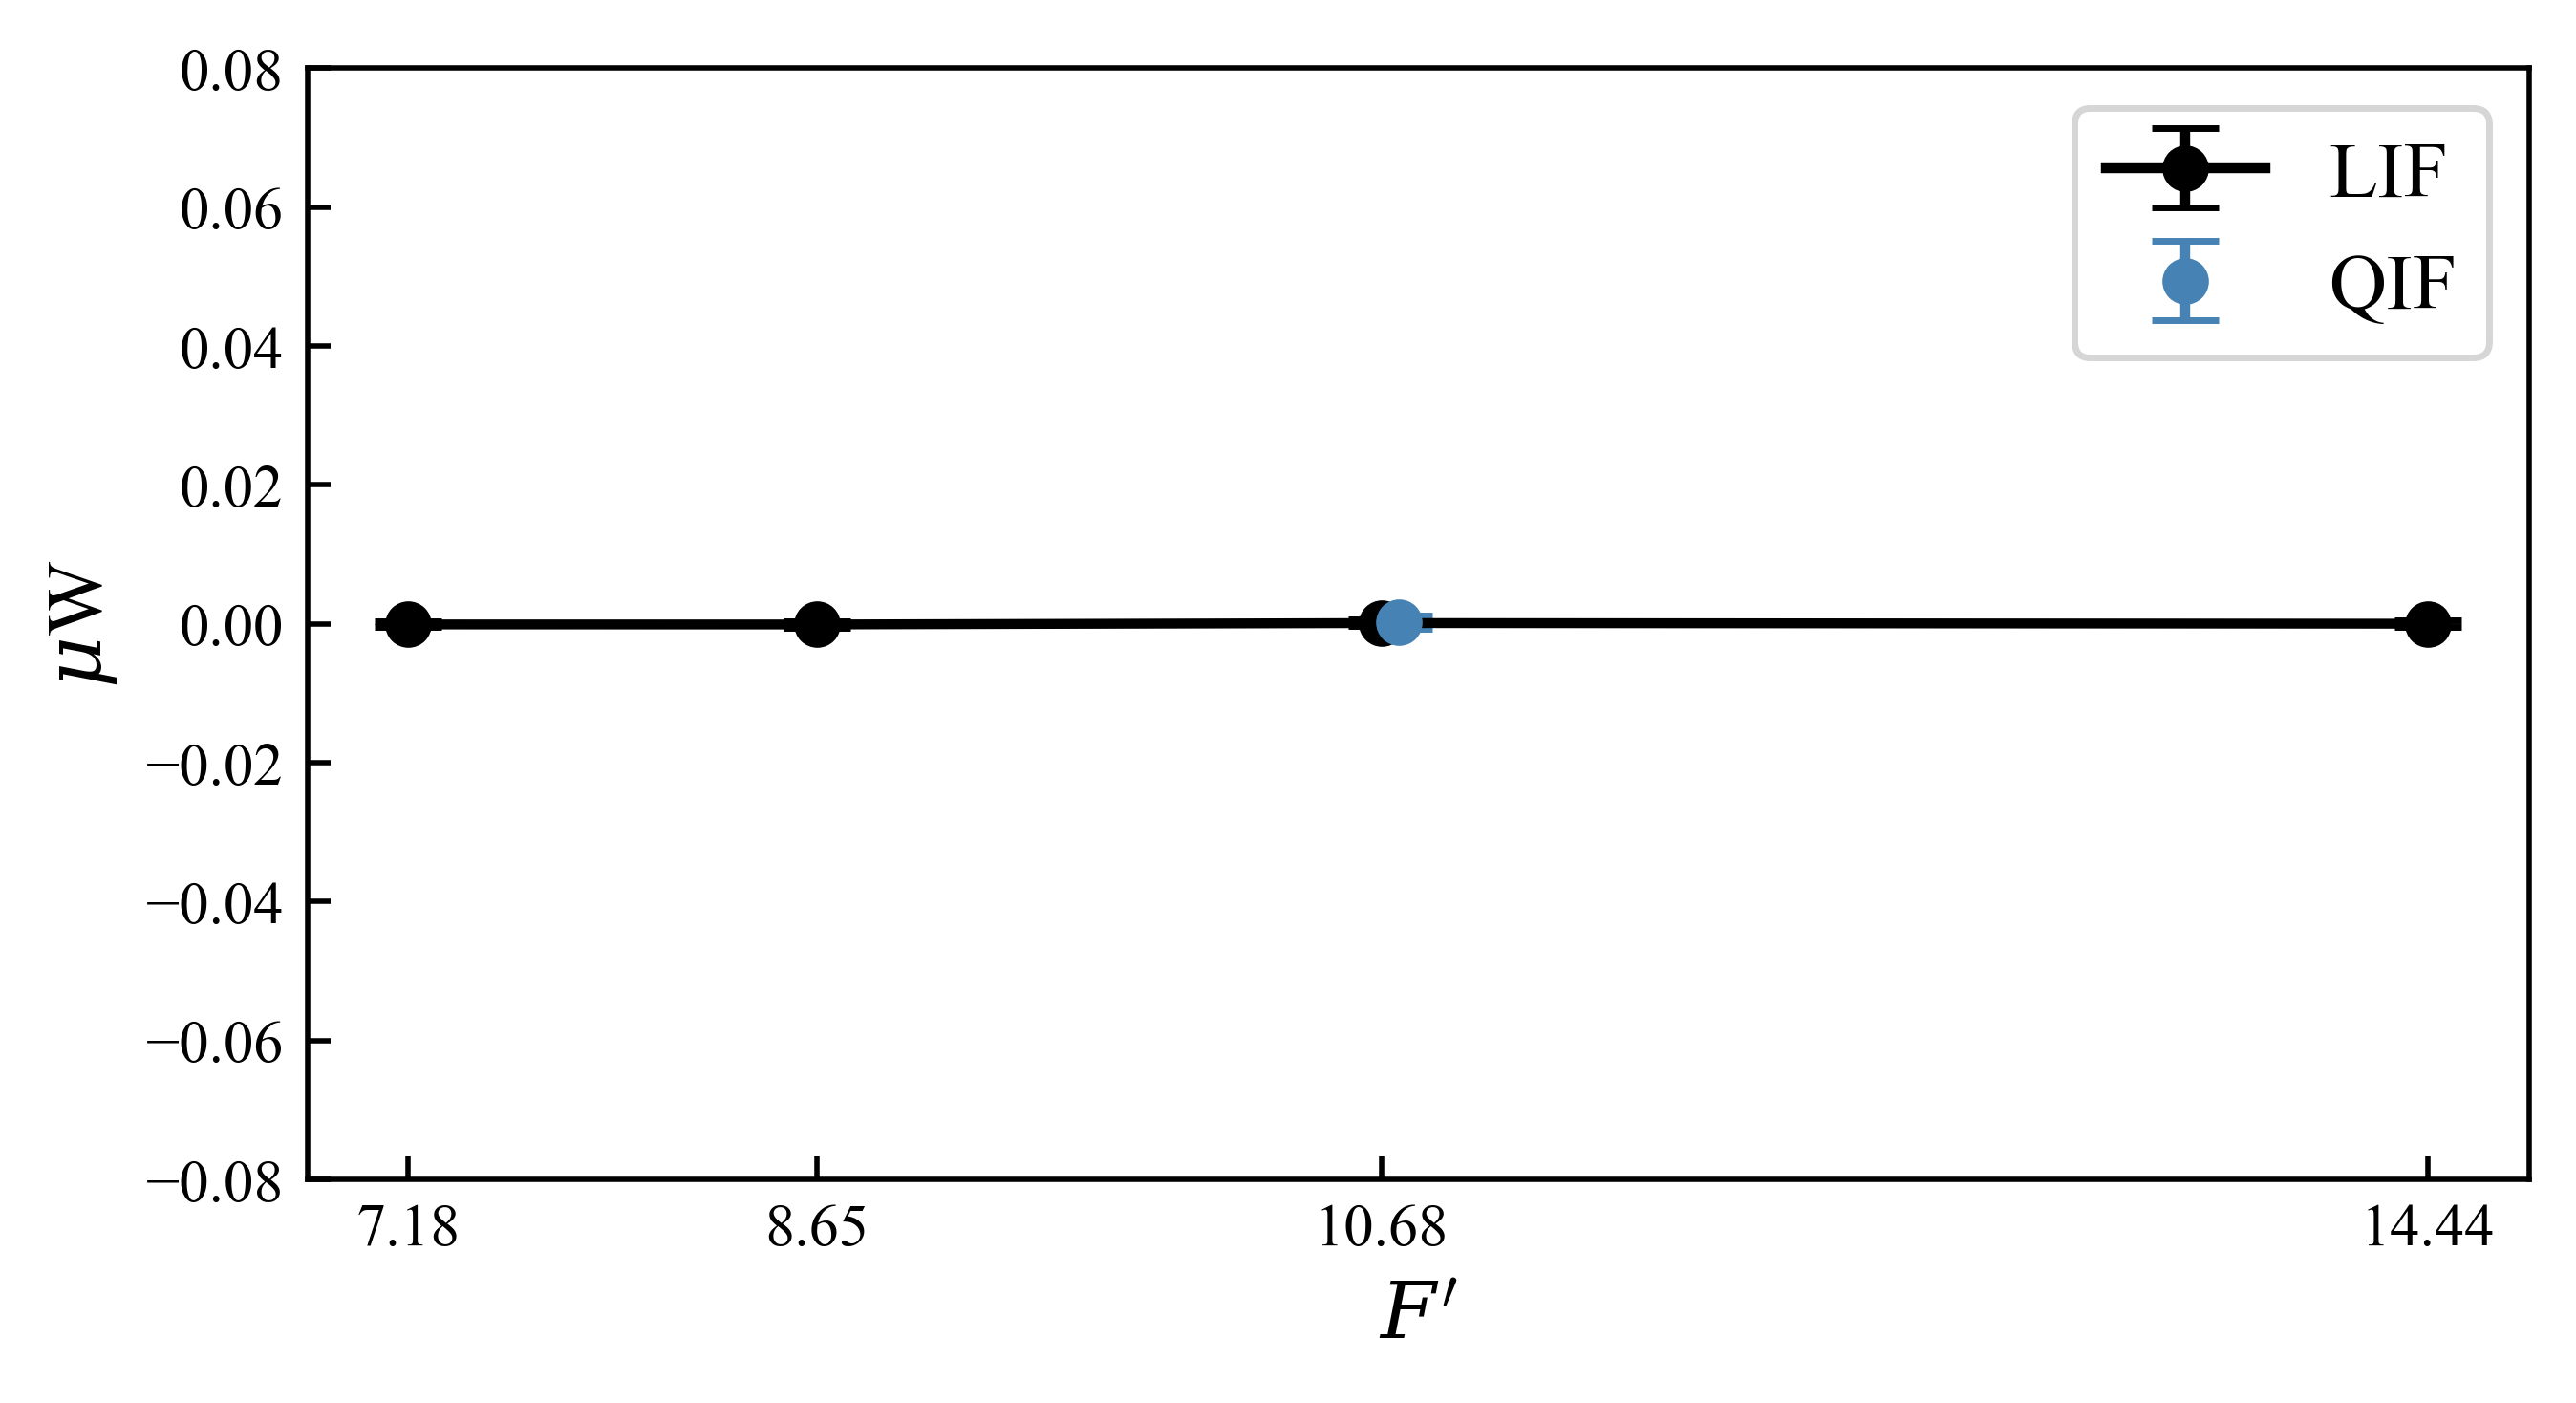

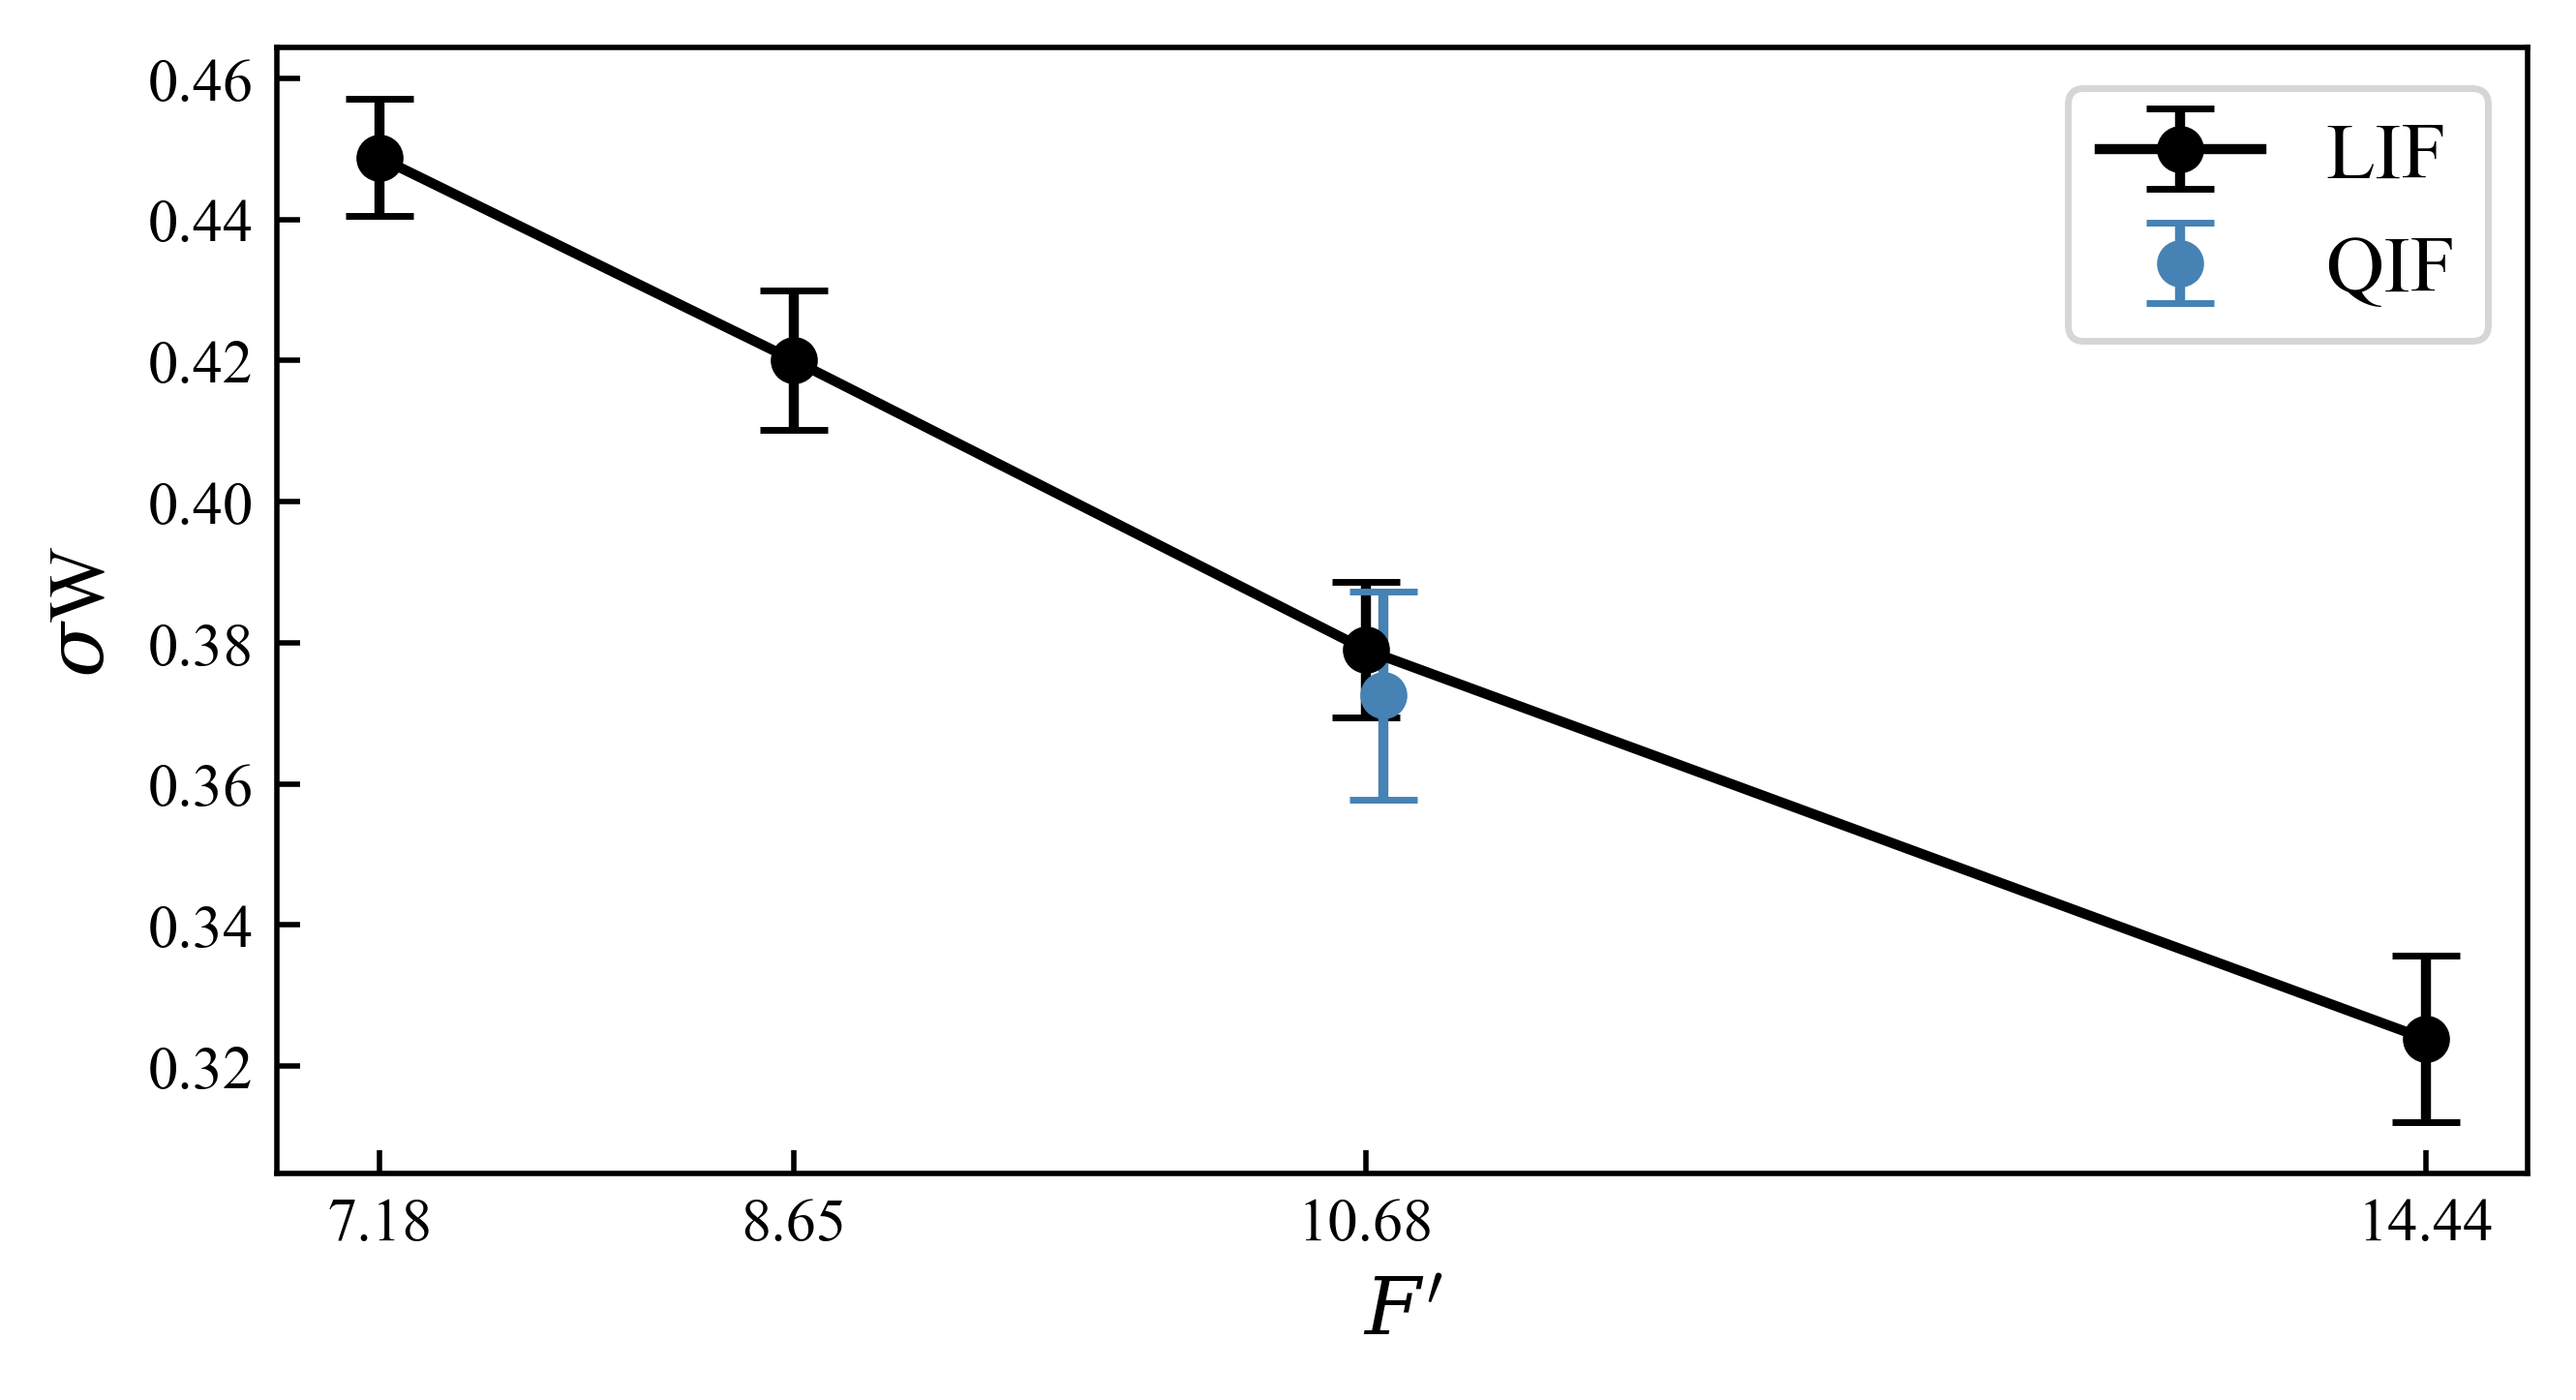

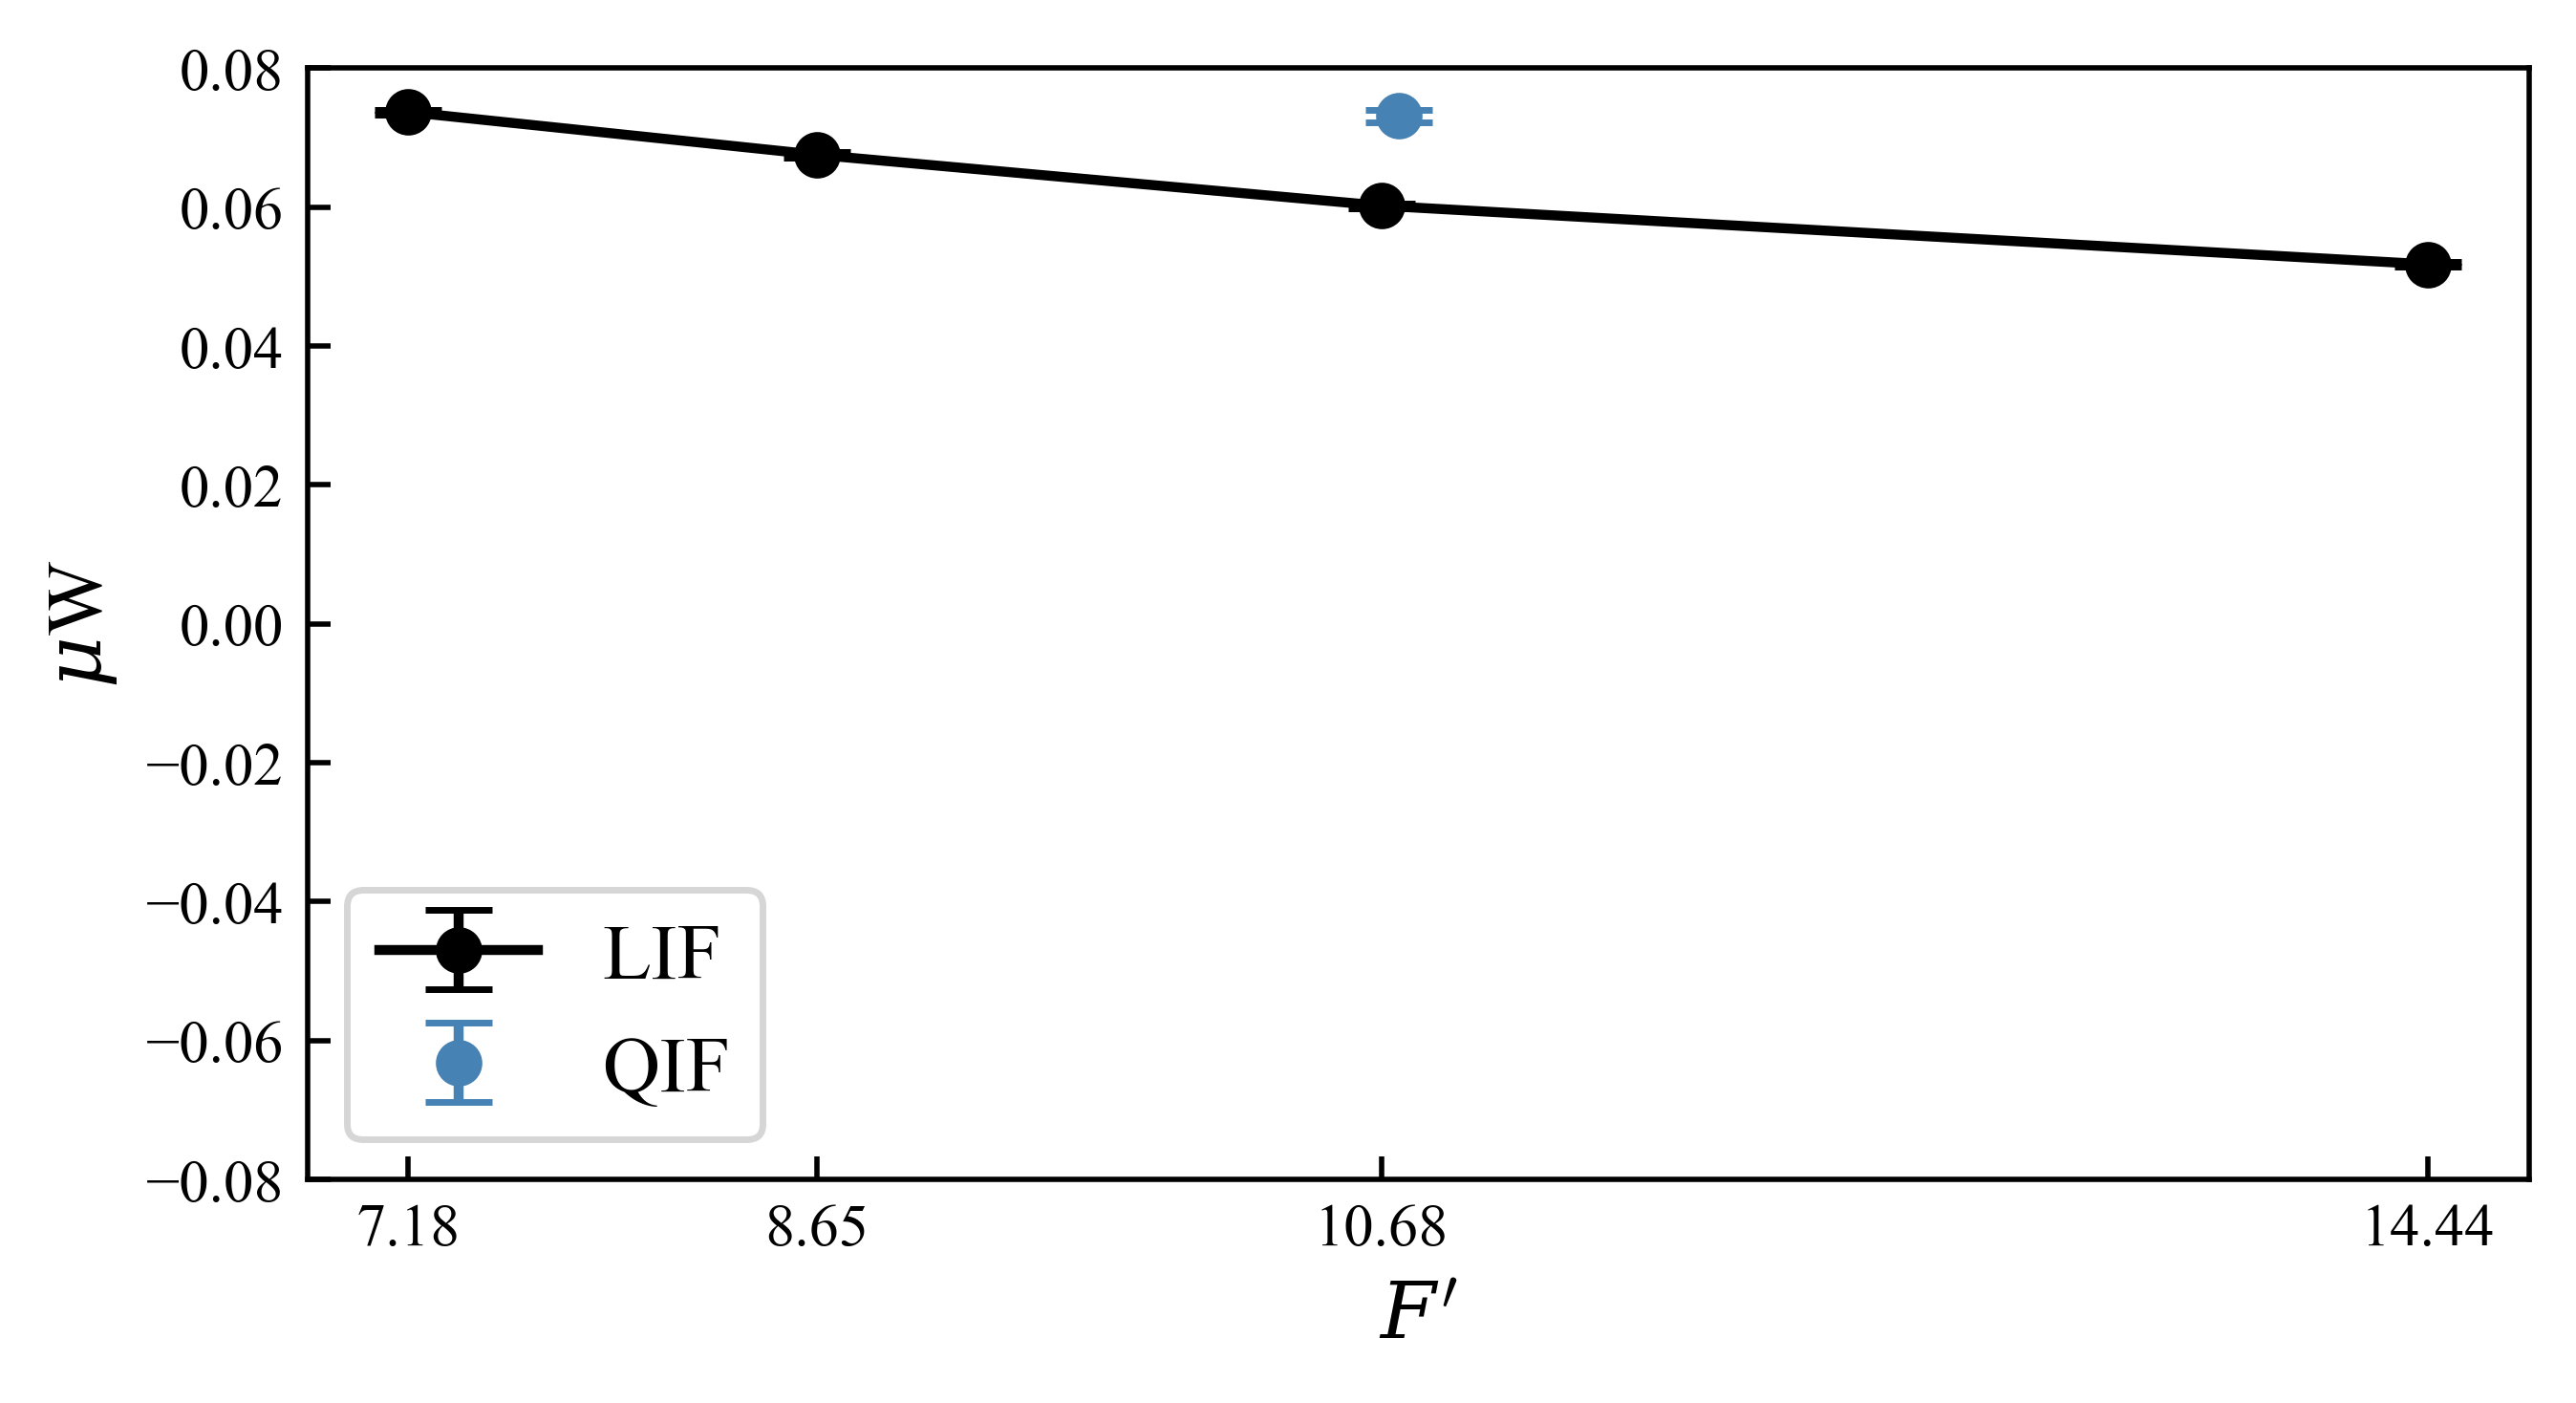

In [19]:
# ========== Standard deviation or Mean of weights vs. slope for homogenous networks ==========

import pandas as pd
import numpy as np
import matplotlib
import sys


########## Loop variables ##########
vrest = [-8.5, -12.3, -17, -22]
slope = [14.44, 10.68, 8.65, 7.18]
slope_qif = 10.74
all_slopes = [14.44, 10.68, 10.74, 8.65, 7.18]

pqif_number = [0, 0.25, 0.5, 0.75, 1]
pqif_homogenous = [0, 1]

dynamics = ['oscillations', 'sequences']
# dynamics = ['oscillations']
seed_number = [i for i in range(0, 50)]

# columns = ['std', 'mean']
columns = ['std_filtered', 'mean_filtered']

x_ticks = [14.44, 10.68, 8.65, 7.18]

########## Figure loop ##########

for dyn in dynamics:

    simulation_number = [i for i in range(1,5)] if dyn == 'oscillations' else [i for i in range(9,13)]

    #### Plot same figures for both STD and mean
    for c in columns:

        figname = f"{dyn}_homogenous_{c}-vs-slope_filtered.svg"
        fig, ax = plt.subplots(figsize=(6, 4))


        for pqif in pqif_homogenous:

            y = []
            yerr = []
            x = slope


            for sim, vr, f in zip(simulation_number, vrest, slope):

                # mean_filtered	std_filtered

                df_filtered = wDF[(wDF['dynamic'] == dyn) & (wDF['simulation'] == sim) & (wDF['pqif'] == pqif)]  # Current row of dataframe with metadata. Include all seeds since we want errorbars

                # Y: Mean of Y
                y_i = df_filtered[c].mean()

                # Y-error: STD of Y
                yerr_i = df_filtered[c].std()

                if pqif == 0: # For LIF: Make list across slope
                    y.append(y_i)
                    yerr.append(yerr_i)

                elif pqif == 1:  # Only one value for QIF since it is the same in each simulation
                    y = y_i
                    yerr = yerr_i

            colors = color_map_pqif[pqif]

            #### Title and labels depending on if STD or mean 

            if c == 'std_filtered':
                # title = f"$\sigma$W vs. $F'$, {dyn.capitalize()}"
                # title = rf"{dyn.capitalize()} (|w| > $\epsilon$ = {eps})"
                xlabel = f"$F'$"
                ylabel = f"$\sigma$W"

            elif c == "mean_filtered":
                # title = f"$\mu$W vs. $F'$, {dyn.capitalize()}"
                # title = f"$\mu$W vs. $F'$"
                xlabel = f"$F'$"
                ylabel = f"$\mu$W"
                ax.set_ylim(-0.08, 0.08)

            #### Plot values on ax

            if pqif == 0:
                label = 'LIF'
                ax.errorbar(x, y, yerr, fmt='o-', capsize=5, color=colors, label=label)

            elif pqif == 1:
                label = 'QIF'
                ax.errorbar(slope_qif, y, yerr, fmt='o', capsize=5, color=colors, label=label)

        # ax.set_title(rf"{dyn.capitalize()} (|w| > $\epsilon$ = {eps})")
        ax.set_xticks(x_ticks)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.set_box_aspect(0.5)

        # if c == "mean":
        #     ax.set_ylim(0, 0.024)
        plt.legend()
        full_path = os.path.join(figure_folder, figname)
        plt.savefig(full_path, format="svg")
        plt.show()



In [14]:
test = wDF.copy()

test[(test['pqif'] != 0) & (test['pqif'] != 1)]

,simulationID,dynamic,simulation,vrest,slope,pqif,seed,std,mean,mean_filtered,std_filtered
50,oscillations_1_0.25_0,oscillations,1,-8.5,14.44,0.25,0,0.252220,0.000327,0.001097,0.461682
51,oscillations_1_0.25_1,oscillations,1,-8.5,14.44,0.25,1,0.240952,0.000172,0.000575,0.441149
52,oscillations_1_0.25_2,oscillations,1,-8.5,14.44,0.25,2,0.241479,0.000361,0.001210,0.442002
53,oscillations_1_0.25_3,oscillations,1,-8.5,14.44,0.25,3,0.251001,0.000487,0.001632,0.459277
54,oscillations_1_0.25_4,oscillations,1,-8.5,14.44,0.25,4,0.247986,0.000320,0.001073,0.453931
...,...,...,...,...,...,...,...,...,...,...,...
1945,sequences_12_0.75_45,sequences,12,-22.0,7.18,0.75,45,0.214739,0.022352,0.074925,0.388116
1946,sequences_12_0.75_46,sequences,12,-22.0,7.18,0.75,46,0.194897,0.022430,0.075168,0.351185
1947,sequences_12_0.75_47,sequences,12,-22.0,7.18,0.75,47,0.218561,0.022220,0.074407,0.395069
1948,sequences_12_0.75_48,sequences,12,-22.0,7.18,0.75,48,0.209134,0.022383,0.075028,0.377702


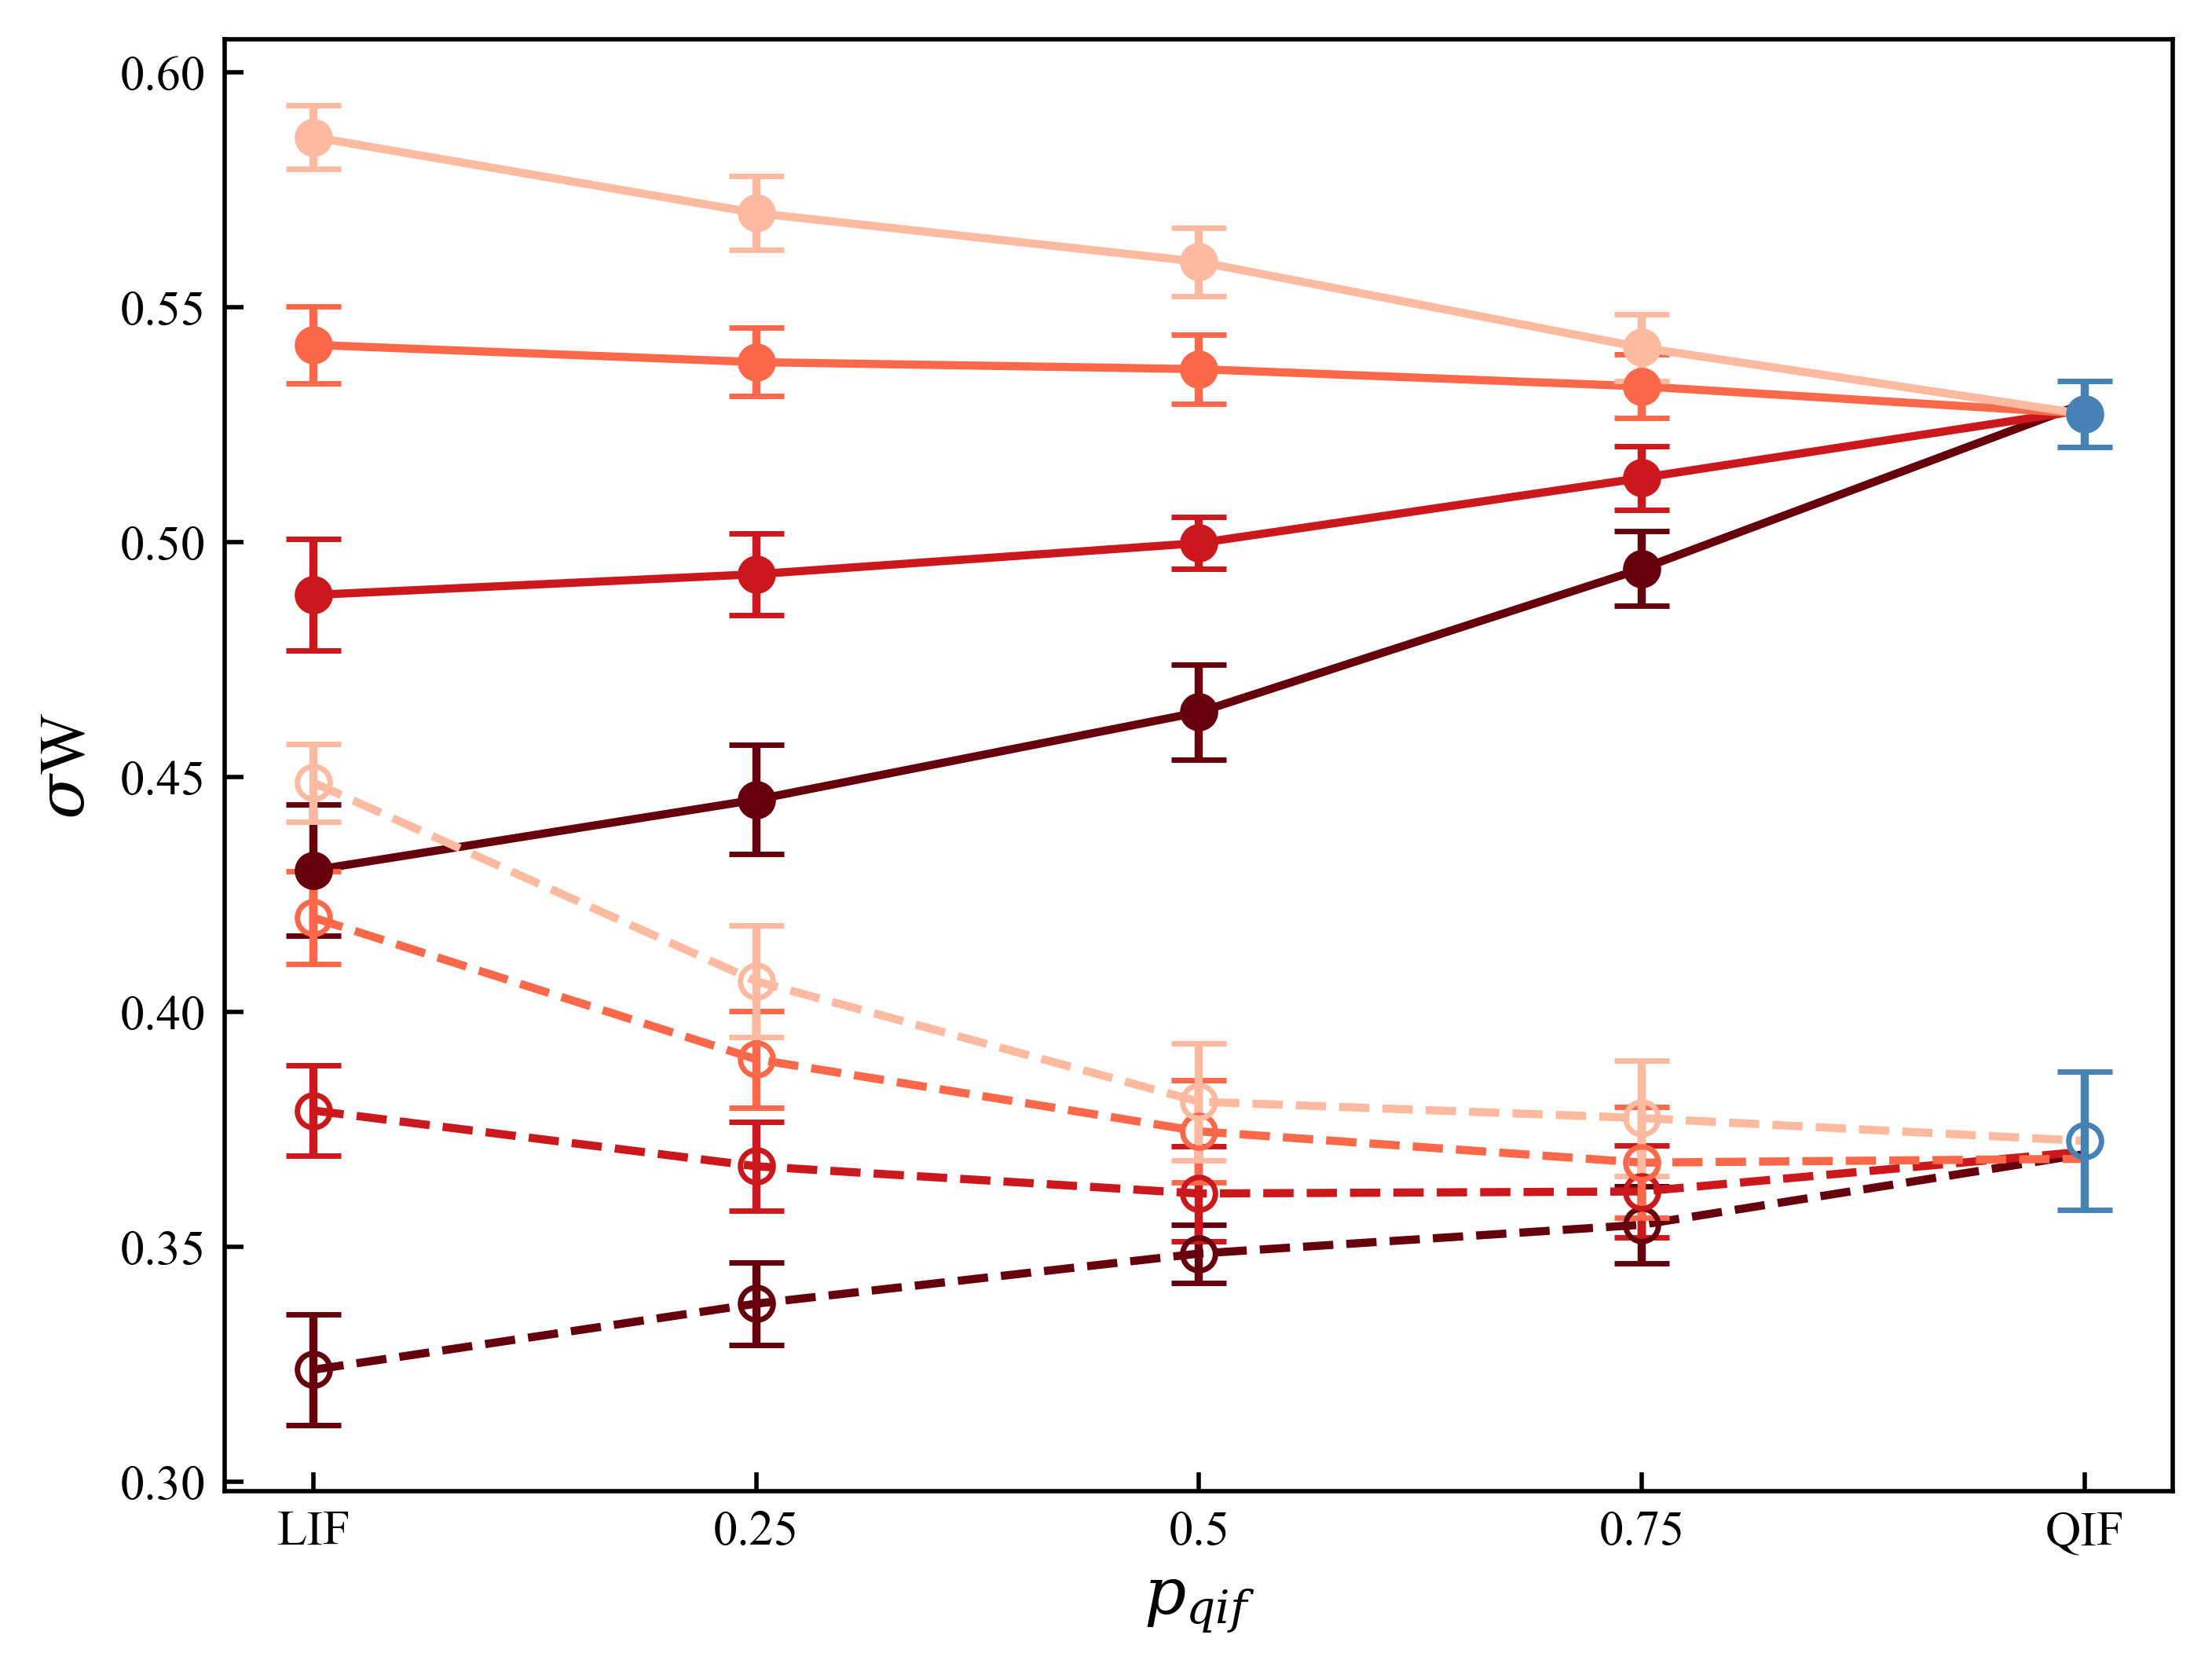

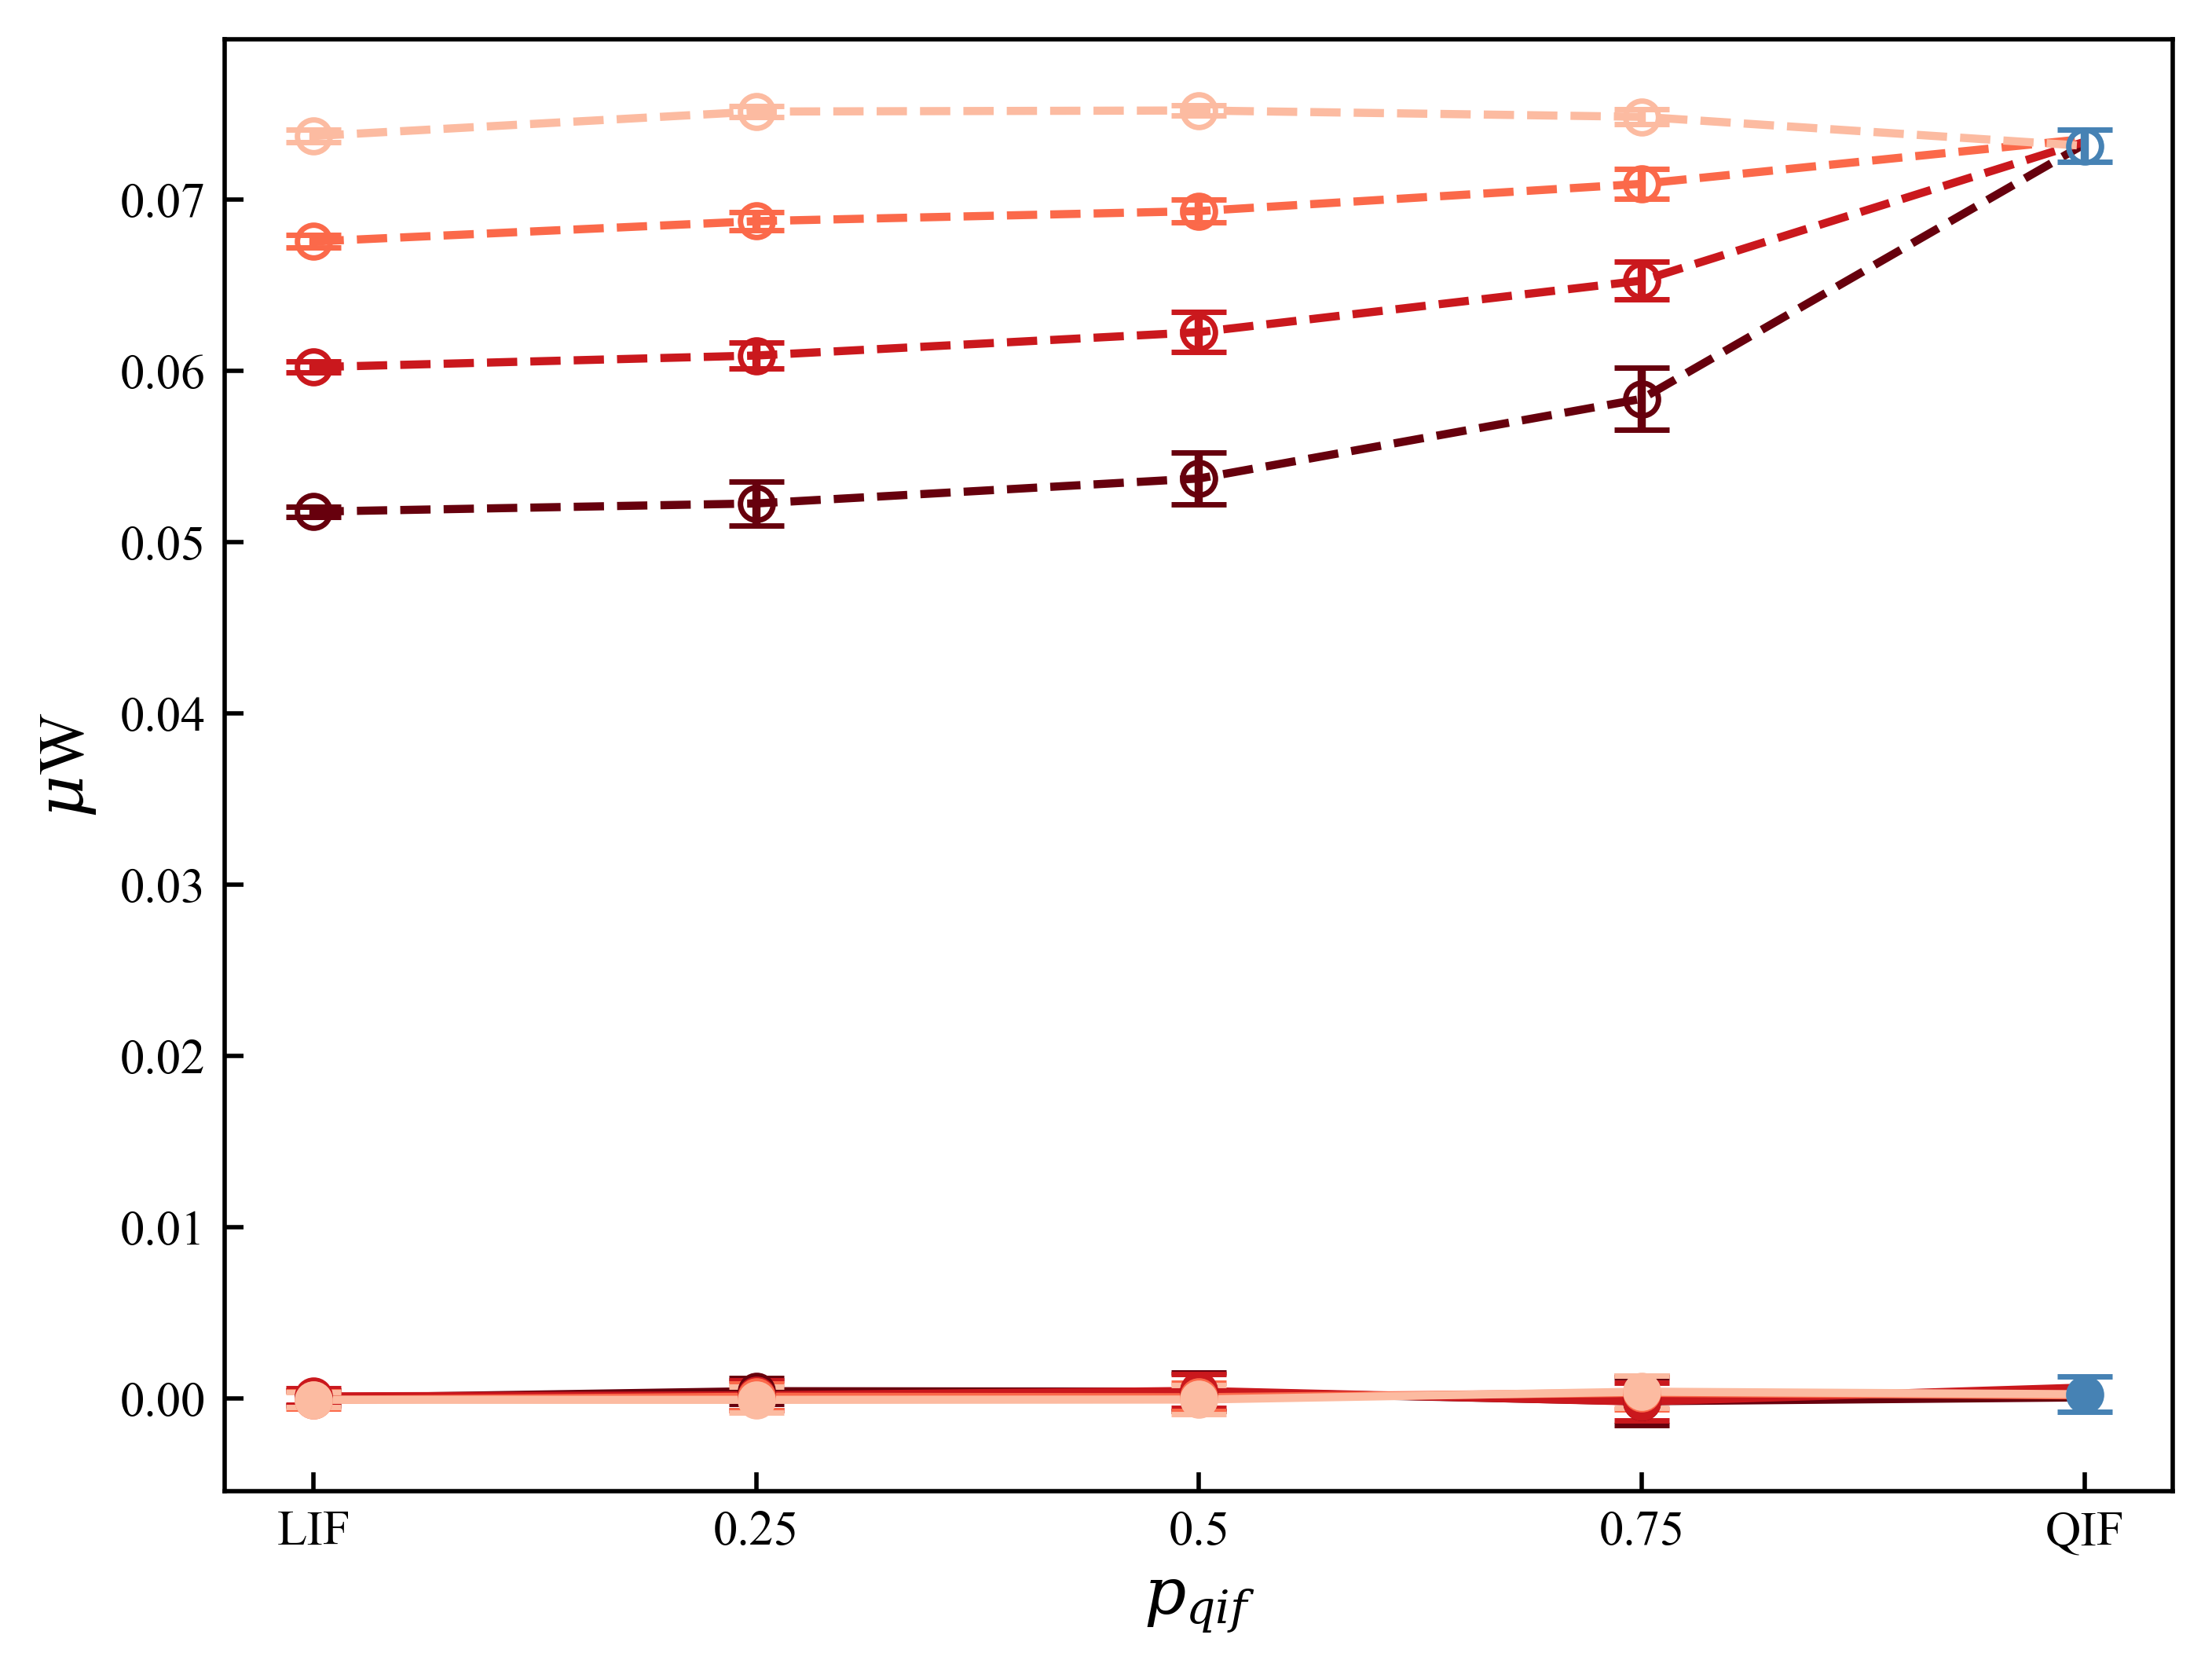

In [22]:
# ========== Mean of weights vs. pqif for heterogenous networks ==========

import pandas as pd
import numpy as np
import matplotlib
import sys


########## Loop variables ##########
vrest = [-8.5, -12.3, -17, -22]
slope = [14.44, 10.68, 8.65, 7.18]
slope_qif = 10.74
all_slopes = [14.44, 10.68, 10.74, 8.65, 7.18]

pqif_number = [0, 0.25, 0.5, 0.75, 1]
pqif_homogenous = [0, 1]

dynamics = ['oscillations', 'sequences']
# dynamics = ['oscillations']
seed_number = [i for i in range(0, 50)]

columns = ['std_filtered', 'mean_filtered']
# columns = ['mean', 'std']

x_ticks = ['LIF', 0.25, 0.5, 0.75, 'QIF']

########## Figure loop ##########

#### Plot same figures for both STD and mean
for c in columns:

    fig, ax = plt.subplots()  # Both dynamics should be in the same figure for this one
    figname = f"both_heterogenous_{c}-vs-pqif_filtered.svg"

    for dyn in dynamics:
        
        simulation_number, fillstyle, linestyle = ([i for i in range(1,5)], 'full', '-') if dyn == 'oscillations' else ([i for i in range(9,13)], 'none', '--')


        for sim, vr, f in zip(simulation_number, vrest, slope):
        

            y = []
            yerr = []
            x = pqif_number

            for pqif in pqif_number:


                df_filtered = wDF[(wDF['dynamic'] == dyn) & (wDF['simulation'] == sim) & (wDF['pqif'] == pqif)]  # Current row of dataframe with metadata. Include all seeds since we want errorbars

                # Y: Mean of Y
                y_i = df_filtered[c].mean()

                # Y-error: STD of Y
                yerr_i = df_filtered[c].std()


                y.append(y_i)
                yerr.append(yerr_i)


            if (sim == simulation_number[0]):
                label = f"LIF\n$F'$={f}"
            else:
                label = f"$F'$={f}"

            if dyn == 'sequences':
                label = None


            ########## For formatting purposes, I plot double to allow connecting lines to QIF without having errorbars on top of eachother for QIF specifically ##########

            no_qif_x = x[:-1]
            no_qif_y = y[:-1]
            no_qif_yerr = yerr[:-1]

            # if dyn == 'oscillations':
            #     linestyle='-'
            # elif dyn == 'sequences':
            #     linestyle = '--'

            # ax.errorbar(x, y, yerr, fmt='o', capsize=5, color=color_map_vrest[vr], label=label)
            ax.errorbar(no_qif_x, no_qif_y, no_qif_yerr, fmt='o', fillstyle=fillstyle, capsize=5, color=color_map_vrest[vr], label=label)
            ax.plot(x, y, linestyle=linestyle, color=color_map_vrest[vr], label=None)

        
        ########## Title and tick labels ##########
        if c == 'std_filtered':
            title = f"$\sigma$W vs. $pqif$ for oscillations & sequences"
            xlabel = f"$p_{{qif}}$"
            ylabel = f"$\sigma$W"

        elif c == "mean_filtered":
            title = f"$\mu$W vs. $pqif$ for oscillations & sequences"
            xlabel = f"$p_{{qif}}$"
            ylabel = f"$\mu$W"


        ########## Add QIF ##########
        df_filtered_qif = wDF[(wDF['dynamic'] == dyn) & (wDF['simulation'] == sim) & (wDF['pqif'] == 1)]

        y_qif = df_filtered_qif[c].mean()  # y
        yerr_qif = df_filtered_qif[c].std()  # y-error
        x_qif = 1  # x

        if dyn == 'oscillations': # first
            label = f"QIF\n$F'$={slope_qif}"
        else:
            label = None


        ax.errorbar(x_qif, y_qif, yerr_qif, fmt='o', capsize=5, fillstyle=fillstyle, color='steelblue', label=label)

    # ax.set_title(rf"{dyn.capitalize()} (|w| > $\epsilon$ = {eps})")
    # ax.set_ylim(-0.02, 0.34) if c == 'std' else ax.set_ylim(-0.002, 0.024)
    ax.set_xlabel(xlabel)
    ax.set_xticks(pqif_number, x_ticks)
    ax.set_ylabel(ylabel)
    # ax.axhline(0, color='black')
    # if dyn == 'oscillations':
    #     ax.set_ylim(-0.02, 0.34)
    # else:
    #     ax.set_ylim(-0.002, 0.024)


    # plt.legend()
    full_path = os.path.join(figure_folder, figname)
    plt.savefig(full_path, format="svg")
    plt.show()


Used seed [31]


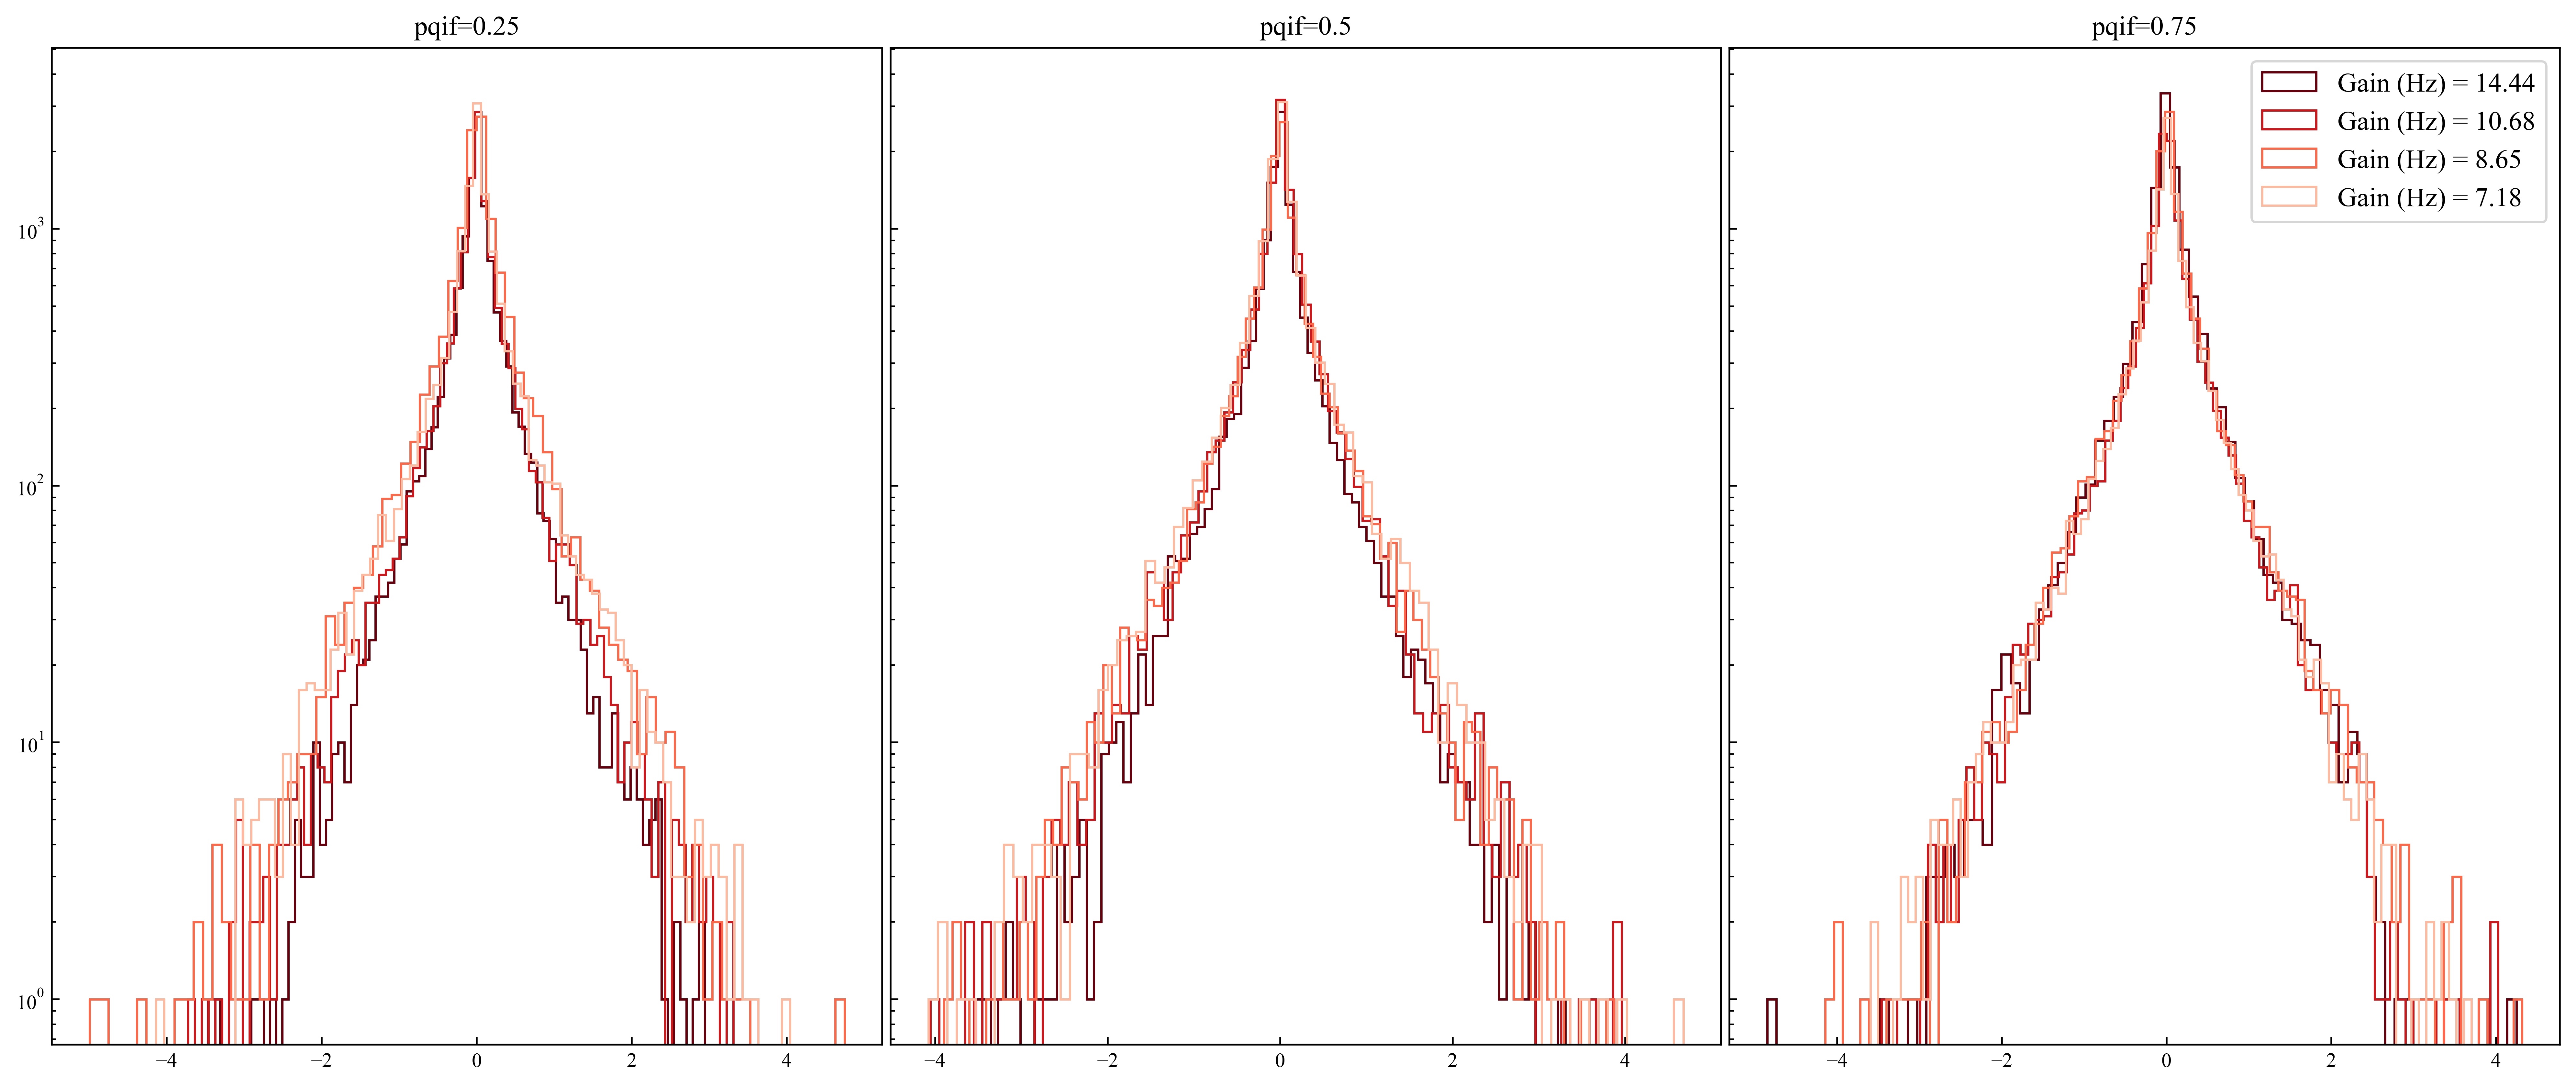

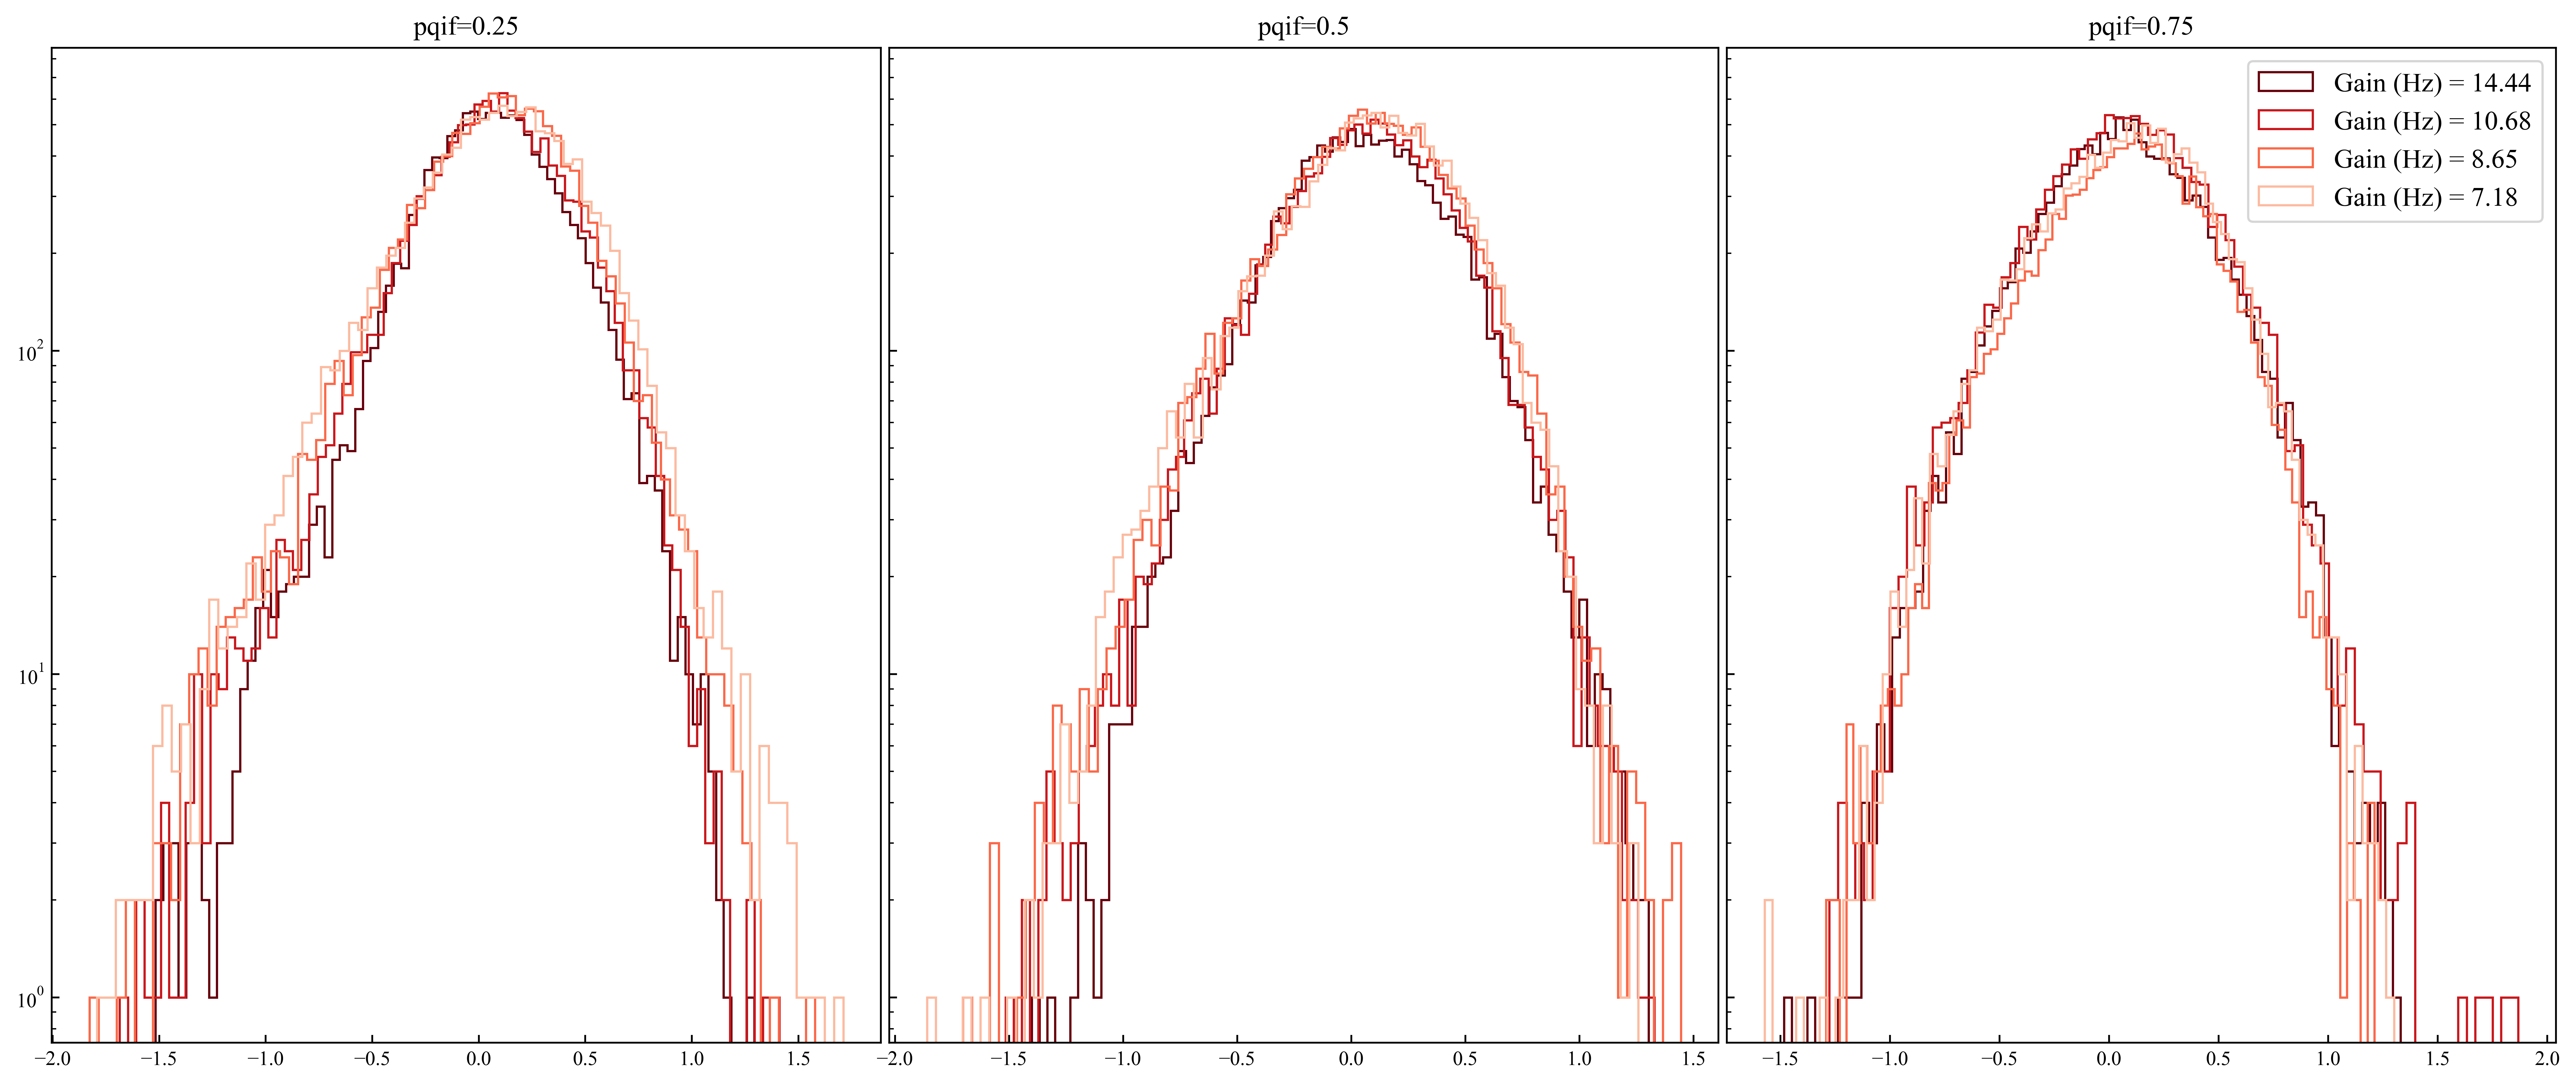

In [13]:
# ========== Histogram of weight distribution for homogenous networks ==========

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import sys
import os
import random
from matplotlib.patches import Patch


########## Loop variables ##########
vrest = [-8.5, -12.3, -17, -22]
slope = [14.44, 10.68, 8.65, 7.18]
slope_qif = [10.74]
all_slopes = [14.44, 10.68, 10.74, 8.65, 7.18]

pqif_number = [0, 0.25, 0.5, 0.75, 1]
pqif_heterogenous = [0.25, 0.5, 0.75]

dynamics = ['oscillations', 'sequences']
# dynamics = ['oscillations']

# seed_number = [i for i in range(0, 1)] # Only use one seed for this
seed_number = [random.randint(1, 49)]
# seed_number = [2] 
print(f"Used seed {seed_number}")

rows = []

########## Figure loop ##########
for dyn in dynamics:

    simulation_number = [i for i in range(1,5)] if dyn == 'oscillations' else [i for i in range(9,13)]
    # simulation_number, vrest, slope = ([1], [-8.5], [14.44])  if dyn == 'oscillations' else ([9], [-8.5], [14.44])

    figname = f"{dyn}_homogenous_histo_weights.svg"

    #### Create figure and axes

    fig, axs = plt.subplots(
        nrows=1, ncols=3,
        figsize=(20,8),  # TODO review
        sharey=True
    )

    fig.subplots_adjust(
    wspace=0.01
)


    #### Figure control flow

    for sim, vr, f in zip(simulation_number, vrest, slope):
        for i, pqif in enumerate(pqif_heterogenous):
            ax = axs[i]
            for seed in seed_number:

                df_filtered = wDF[(wDF['dynamic'] == dyn) & (wDF['simulation'] == sim) & (wDF['pqif'] == pqif) & (wDF['seed'] == seed)]  # Current row of dataframe with metadata

                ID = df_filtered['simulationID'].item()  # Simulation ID

                # current_weights_noflatten = weights_dict[ID].to_numpy()  # Weight array not flattened
                # current_weights = current_weights_noflatten.flatten()

                current_weights = weights_filtered_dict[ID]

                std = current_weights.std()
                mn = current_weights.mean()

                color = color_map_vrest[vr]

                label = f"Gain (Hz) = {f}"


                ax.hist(current_weights, bins=80, log=True, color=color, alpha=1, linewidth=1, histtype='step', label=label)

                ax.set_title(f"pqif={pqif}")


    # plt.suptitle(rf"{dyn.capitalize()} (|w| > $\epsilon$ = {eps})")

    plt.legend()
    plt.show()


# 2